# Regulación de Alquileres y Dinámica del Mercado de Vivienda en Barcelona
## `rent_bcn_v2_modelos.ipynb` — Fase de Modelización

---

**Proyecto:** Dinámica del Mercado de Alquiler en Barcelona  
**Dataset:** Generalitat de Catalunya · 2000–2025 · 66 barrios · 10 distritos  
**Integrantes:** Katherine Soto · Juan Ortega  
**Objetivo:** Cuantificar el efecto causal de los sucesivos cambios regulatorios sobre la actividad contractual y el precio real del alquiler en Barcelona mediante tres módulos complementarios: regresión de panel con efectos fijos, clasificación supervisada de episodios de contracción y análisis de series temporales con ruptura estructural.

---
# 0. Setup y carga de datos

Cargamos todas las librerías necesarias agrupadas por función. El entorno de reproducibilidad queda fijado con `RANDOM_STATE = 42` en todos los estimadores estocásticos.

In [1]:
# Librerias de manipulacion de datos
import numpy as np
import pandas as pd
from pathlib import Path

# Librerias de visualizacion
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Librerias de modelos de panel (regresion)
from linearmodels.panel import PanelOLS, PooledOLS
from linearmodels.panel import compare

# Librerias de machine learning (clasificacion)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Librerias de series temporales
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Librerias de inferencia
from scipy import stats
from scipy.stats import shapiro

# Configuracion de visualizacion
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette('muted')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Setup completado correctamente.')


Setup completado correctamente.


## 0.1 Carga de datos

Cargamos los dos dataframes principales desde los parquets generados en el EDA. Verificamos forma, rango temporal y que no se hayan perdido barrios ni distritos en el proceso de persistencia.

In [2]:
# Rutas a los parquets -- ajustar segun entorno local
# PATH_BARRIOS   = Path('../data_bcn/neighborhood_final.parquet')
# PATH_DISTRITOS = Path('../data_bcn/districts_final.parquet')
from pathlib import Path
import os

# Detecta el directorio raíz del proyecto
PROJECT_ROOT = Path(__file__).parent.parent if '__file__' in dir() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data_cleaned'

PATH_BARRIOS   = DATA_DIR / 'df_barrios_eda.parquet'
PATH_DISTRITOS = DATA_DIR / 'df_distritos_eda.parquet'

df_barrios_raw   = pd.read_parquet(PATH_BARRIOS)
df_distritos_raw = pd.read_parquet(PATH_DISTRITOS)

print('Barrios   -- shape:', df_barrios_raw.shape)
print('Distritos -- shape:', df_distritos_raw.shape)


Barrios   -- shape: (3102, 29)
Distritos -- shape: (1030, 27)


## 0.2 Reproducir la limpieza mínima del EDA

Aplicamos exactamente las mismas decisiones de limpieza documentadas en el EDA:

- Eliminamos el trimestre Q4-2025 (publicación incompleta).  
- Excluimos los 7 barrios de mercado delgado para el análisis de precios y dinámica contractual.  
- Recodificamos ceros anómalos en variables de actividad como `NaN` para que no distorsionen los modelos.

In [3]:
BARRIOS_PROBLEMATICOS = [
    'Baro de Viver',
    'Can Peguera',
    'Canyelles',
    'Torre Baro',
    'Vallbona',
    'la Clota',
    'la Marina del Prat Vermell - AEI Zona Franca'
]

# Barrios: eliminar 2025Q4 y barrios de mercado delgado
df_barrios = (
    df_barrios_raw
    .loc[~((df_barrios_raw['year'] == 2025) & (df_barrios_raw['quarter'] == 4))]
    .loc[~df_barrios_raw['neighborhood'].isin(BARRIOS_PROBLEMATICOS)]
    .copy()
)

# Recodificar ceros anomalos como NaN en variables de mercado
for col in ['avg_rent', 'avg_rent_m2', 'avg_surface']:
    df_barrios.loc[df_barrios[col] == 0, col] = np.nan

# Distritos: eliminar 2025Q4
df_distritos = (
    df_distritos_raw
    .loc[~((df_distritos_raw['year'] == 2025) & (df_distritos_raw['quarter'] == 4))]
    .copy()
)

print('Barrios limpios   -- shape:', df_barrios.shape)
print('Barrios unicos:', df_barrios['neighborhood'].nunique())
print('Distritos limpios -- shape:', df_distritos.shape)
print('Rango temporal barrios:', df_barrios['date'].min(), '->', df_barrios['date'].max())


Barrios limpios   -- shape: (3102, 29)
Barrios unicos: 66
Distritos limpios -- shape: (1030, 27)
Rango temporal barrios: 2014-01-01 00:00:00 -> 2025-07-01 00:00:00


## 0.3 Construir los datasets analíticos

Preparamos las versiones finales para cada módulo:

- **Panel (regresión y clasificación):** `df_barrios_eda` — estructura barrio × trimestre, 66 unidades, horizonte 2000–2025.  
- **Serie temporal:** `city_ts` — serie agregada de Barcelona construida desde distritos con medias ponderadas por `num_contracts`, 103 observaciones trimestrales.

In [4]:
# Copias de trabajo con tipos correctos
df_barrios_eda   = df_barrios.copy()
df_distritos_eda = df_distritos.copy()

for df in [df_barrios_eda, df_distritos_eda]:
    for col in ['post_regulation', 'covid_dummy']:
        df[col] = df[col].astype(bool)

df_barrios_eda['neighborhood'] = df_barrios_eda['neighborhood'].astype('category')
df_distritos_eda['district']   = df_distritos_eda['district'].astype('category')

# Etiquetas de 4 periodos -- misma logica que en el EDA
def assign_period_4levels(df):
    q_int = df['quarter'].astype(int)
    conditions = [
        (df['year'] <= 2019),
        (df['year'] == 2020) & q_int.isin([1, 2, 3]),
        ((df['year'] == 2020) & (q_int == 4)) | (df['year'] == 2021),
        (df['year'] >= 2022)
    ]
    choices = [
        'Pre-COVID / pre-regulation',
        'COVID shock',
        'Regulation + COVID / transition',
        'Post-overlap / new regime'
    ]
    out = df.copy()
    out['period_4levels'] = np.select(conditions, choices, default='Unknown')
    out['period_4levels'] = pd.Categorical(out['period_4levels'], categories=choices, ordered=True)
    return out

df_barrios_eda   = assign_period_4levels(df_barrios_eda)
df_distritos_eda = assign_period_4levels(df_distritos_eda)

print('Distribucion de periodos en barrios:')
print(df_barrios_eda['period_4levels'].value_counts().sort_index())


# ── Periodización de 5 niveles (alineada con eda_limpio_v1.ipynb) ──────────
ORDER_5 = [
    'Pre-COVID / pre-regulation',
    'COVID shock',
    'Ley 11/2020 activa',
    'Desregulación TC (gap)',
    'Ley 12/2023 / zona tensionada',
]
BREAKS_5 = {
    'COVID shock'                  : pd.Timestamp('2020-01-01'),
    'Ley 11/2020 activa'           : pd.Timestamp('2020-10-01'),
    'Desregulación TC (gap)'       : pd.Timestamp('2022-04-01'),
    'Ley 12/2023 / zona tensionada': pd.Timestamp('2023-07-01'),
}

def assign_period_5levels(df_in):
    """
    Añade period_5levels (categorical) y las 3 dummies binarias de régimen:
      D_ley11  : Ley 11/2020 activa  (Q4 2020 – Q1 2022)
      D_tc_gap : Desregulación TC    (Q2 2022 – Q2 2023)
      D_ley12  : Ley 12/2023         (Q3 2023 – presente)
    La categoría de referencia implícita es Pre-COVID / pre-regulation.
    """
    df_out = df_in.copy()
    dt = pd.to_datetime(df_out['date'])

    df_out['period_5levels'] = pd.Categorical(
        np.select(
            [
                dt < BREAKS_5['COVID shock'],
                dt < BREAKS_5['Ley 11/2020 activa'],
                dt < BREAKS_5['Desregulación TC (gap)'],
                dt < BREAKS_5['Ley 12/2023 / zona tensionada'],
            ],
            ORDER_5[:4],
            default=ORDER_5[4]
        ),
        categories=ORDER_5,
        ordered=True
    )
    df_out['D_ley11']  = ((dt >= BREAKS_5['Ley 11/2020 activa']) &
                          (dt <  BREAKS_5['Desregulación TC (gap)'])).astype(int)
    df_out['D_tc_gap'] = ((dt >= BREAKS_5['Desregulación TC (gap)']) &
                          (dt <  BREAKS_5['Ley 12/2023 / zona tensionada'])).astype(int)
    df_out['D_ley12']  = (dt >= BREAKS_5['Ley 12/2023 / zona tensionada']).astype(int)
    return df_out

df_barrios_eda   = assign_period_5levels(df_barrios_eda)
df_distritos_eda = assign_period_5levels(df_distritos_eda)

print('\nDistribución 5 períodos — barrios:')
print(df_barrios_eda['period_5levels'].value_counts().sort_index())
print('\nDistribución dummies régimen — barrios:')
print(df_barrios_eda[['D_ley11','D_tc_gap','D_ley12']].sum())


Distribucion de periodos en barrios:
period_4levels
Pre-COVID / pre-regulation         1584
COVID shock                         198
Regulation + COVID / transition     330
Post-overlap / new regime           990
Name: count, dtype: int64

Distribución 5 períodos — barrios:
period_5levels
Pre-COVID / pre-regulation       1584
COVID shock                       198
Ley 11/2020 activa                396
Desregulación TC (gap)            330
Ley 12/2023 / zona tensionada     594
Name: count, dtype: int64

Distribución dummies régimen — barrios:
D_ley11     396
D_tc_gap    330
D_ley12     594
dtype: int64


In [5]:
# Media ponderada robusta -- replica exacta de la funcion del EDA
def weighted_mean(values, weights):
    values  = pd.Series(values)
    weights = pd.Series(weights)
    mask = values.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan
    v, w = values[mask], weights[mask]
    return np.nan if w.sum() == 0 else np.average(v, weights=w)


# Construir serie temporal agregada de Barcelona desde distritos
rows = []
for dt, g in df_distritos_eda.groupby('date', as_index=False):
    rows.append({
        'date':                      dt,
        'year':                      g['year'].iloc[0],
        'quarter':                   g['quarter'].astype(int).iloc[0],
        'num_contracts':             int(g['num_contracts'].sum()),
        'avg_rent_m2':               weighted_mean(g['avg_rent_m2'],               g['num_contracts']),
        'avg_rent_m2_real_2025base': weighted_mean(g['avg_rent_m2_real_2025base'],  g['num_contracts']),
        'ipc_index_q':               g['ipc_index_q'].iloc[0]    if 'ipc_index_q'    in g.columns else np.nan,
        'euribor_12m_q':             g['euribor_12m_q'].iloc[0]  if 'euribor_12m_q'  in g.columns else np.nan,
        'post_regulation':           bool(g['post_regulation'].iloc[0]),
        'covid_dummy':               bool(g['covid_dummy'].iloc[0]),
        'contract_growth_yoy':       weighted_mean(g['contract_growth_yoy'],       g['num_contracts']),
        'rent_m2_growth_yoy':        weighted_mean(g['rent_m2_growth_yoy'],        g['num_contracts']),
        'rent_m2_real_growth_yoy':   weighted_mean(g['rent_m2_real_growth_yoy'],   g['num_contracts']),
    })

city_ts = pd.DataFrame(rows).sort_values('date').reset_index(drop=True)

print('Serie agregada Barcelona -- shape:', city_ts.shape)
print(city_ts[['date', 'num_contracts', 'avg_rent_m2', 'avg_rent_m2_real_2025base']].tail())


Serie agregada Barcelona -- shape: (103, 13)
          date  num_contracts  avg_rent_m2  avg_rent_m2_real_2025base
98  2024-07-01           7065      15.7472                    16.0830
99  2024-10-01           7273      15.8881                    16.1826
100 2025-01-01           7595      16.2087                    16.3745
101 2025-04-01           7310      16.5839                    16.5868
102 2025-07-01           7834      16.8511                    16.8000


---
# 1. Módulo de Regresión — Panel de Datos

## 1.1 Objetivo y formulación econométrica

Nuestro objetivo es estimar la asociación entre los sucesivos cambios regulatorios y la evolución de la **actividad contractual** en los barrios de Barcelona, controlando por características no observables fijas de cada barrio.

### Modelo general de efectos fijos (within estimator)

$$y_{it} = \alpha_i + \mathbf{x}_{it}'\boldsymbol{\beta} + \varepsilon_{it}$$

| Símbolo | Definición |
|---------|-----------|
| $y_{it}$ | `contract_growth_yoy`: crecimiento interanual del nº de contratos en el barrio $i$ en el trimestre $t$ |
| $\alpha_i$ | Efecto fijo de barrio: absorbe toda la heterogeneidad no observada **invariante en el tiempo** (ubicación, composición socioeconómica, stock de vivienda) |
| $\mathbf{x}_{it}$ | Vector de covariables que varían en el tiempo |
| $\boldsymbol{\beta}$ | Vector de parámetros de interés |
| $\varepsilon_{it}$ | Error idiosincrático |

### Estimador within (demeaning)

El estimador de efectos fijos elimina $\alpha_i$ centrado cada variable en su media individual:

$$\tilde{y}_{it} = y_{it} - \bar{y}_i, \qquad \tilde{\mathbf{x}}_{it} = \mathbf{x}_{it} - \bar{\mathbf{x}}_i$$

$$\hat{\boldsymbol{\beta}}_{WG} = \left(\tilde{X}'\tilde{X}\right)^{-1}\tilde{X}'\tilde{y}$$

### Errores estándar clusterizados

Para corregir la correlación serial dentro de cada barrio usamos errores clusterizados a nivel de entidad:

$$\hat{V}_{cluster} = \left(X'X\right)^{-1} \left(\sum_{i=1}^{N} X_i' \hat{\boldsymbol{\varepsilon}}_i \hat{\boldsymbol{\varepsilon}}_i' X_i\right) \left(X'X\right)^{-1}$$

Esto nos protege frente a heterocedasticidad y autocorrelación de orden arbitrario dentro de cada barrio, sin imponer estructura paramétrica sobre el proceso de error.

### Supuestos de identificación

- **Exogeneidad estricta:** $\mathbb{E}[\varepsilon_{it} \mid \mathbf{x}_{i1},\ldots,\mathbf{x}_{iT}, \alpha_i] = 0$. Dado que la regulación es una política de ámbito municipal, no existe variación transversal explotable entre barrios tratados y no tratados dentro de Barcelona; la identificación descansa en la variación temporal.  
- **No multicolinealidad perfecta** entre covariables time-varying.

## 1.2 Preparación del dataset para el panel

El estimador de `linearmodels.PanelOLS` requiere un `MultiIndex` (entidad, tiempo). Preparamos esa estructura y nos quedamos únicamente con las observaciones donde la variable dependiente está disponible.

In [6]:
FEATURES_PANEL = [
    'neighborhood', 'date',
    'contract_growth_yoy',
    'avg_rent_m2', 'avg_rent_m2_real_2025base',
    'avg_surface', 'post_regulation', 'covid_dummy',
    'euribor_12m_q', 'ipc_index_q', 'year', 'quarter',
    'D_ley11', 'D_tc_gap', 'D_ley12'   # dummies de régimen regulatorio (5 niveles)
]

df_panel = (
    df_barrios_eda[FEATURES_PANEL]
    .dropna(subset=['contract_growth_yoy'])
    .copy()
)

# Convertir a tipos numericos para linearmodels
df_panel['quarter']        = df_panel['quarter'].astype(int)
df_panel['post_regulation'] = df_panel['post_regulation'].astype(int)
df_panel['covid_dummy']    = df_panel['covid_dummy'].astype(int)

# Dummies de trimestre para controlar estacionalidad (Q1 es la categoria base)
q_dummies = pd.get_dummies(df_panel['quarter'], prefix='q', drop_first=True).astype(int)
df_panel   = pd.concat([df_panel.drop(columns='quarter'), q_dummies], axis=1)

# MultiIndex requerido por linearmodels: (entidad, tiempo)
df_panel = df_panel.set_index(['neighborhood', 'date'])

print('Dataset panel -- shape:', df_panel.shape)
print('Observaciones por barrio (promedio):', round(df_panel.groupby(level=0).size().mean(), 1))
print('Nulos en contract_growth_yoy:', df_panel['contract_growth_yoy'].isna().sum())


Dataset panel -- shape: (2838, 15)
Observaciones por barrio (promedio): 43.0
Nulos en contract_growth_yoy: 0


## 1.3 Especificaciones del modelo

Estimamos cuatro especificaciones en orden de complejidad creciente. La estrategia es evaluar la **estabilidad del coeficiente de regulación** al añadir controles.

---

### M1 — Baseline regulatorio

$$y_{it} = \alpha_i + \beta_1 \, \text{post\_regulation}_{t} + \beta_2 \, \text{covid\_dummy}_{t} + \varepsilon_{it}$$

Solo las dummies de régimen regulatorio. Captura el efecto bruto sin ningún control. $\beta_1$ es el parámetro de interés primario.

---

### M2 — + Precio y superficie

$$y_{it} = \alpha_i + \beta_1 \, \text{post\_regulation}_{t} + \beta_2 \, \text{covid\_dummy}_{t} + \beta_3 \, \text{avg\_rent\_m2}_{it} + \beta_4 \, \text{avg\_surface}_{it} + \varepsilon_{it}$$

Añadimos el precio nominal por m² y la superficie media como controles de la composición del mercado local. Si $\hat{\beta}_1$ cae respecto a M1, parte de la señal bruta la captaba el encarecimiento del alquiler.

---

### M3 — + Euribor y estacionalidad trimestral

$$y_{it} = \alpha_i + \beta_1 \, \text{post\_regulation}_{t} + \beta_2 \, \text{covid\_dummy}_{t} + \beta_3 \, \text{avg\_rent\_m2}_{it} + \beta_4 \, \text{avg\_surface}_{it} + \beta_5 \, \text{euribor}_{t} + \sum_{q=2}^{4} \delta_q Q_{qt} + \varepsilon_{it}$$

Incorporamos el Euribor a 12 meses como proxy del coste de financiación hipotecaria y tres dummies trimestrales para controlar la estacionalidad de los contratos. Es la especificación completa de referencia.

---

### M4 — 3 regímenes regulatorios

$$y_{it} = \alpha_i + \beta_1 D_{ley11,t} + \beta_2 D_{tc,t} + \beta_3 D_{ley12,t} + \beta_4 \, \text{covid}_{t} + \beta_5 \, \text{avg\_rent\_m2}_{it} + \beta_6 \, \text{avg\_surface}_{it} + \beta_7 \, \text{euribor}_{t} + \sum_{q=2}^{4} \delta_q Q_{qt} + \varepsilon_{it}$$

Sustituimos la dummy binaria `post_regulation` por tres indicadores mutuamente excluyentes que capturan la granularidad del calendario regulatorio:

| Dummy | Período activo | Hito |
|-------|---------------|------|
| $D_{ley11}$ | Q4 2020 – Q1 2022 | Ley 11/2020 de contención de rentas |
| $D_{tc}$ | Q2 2022 – Q2 2023 | Sentencia TC: nulidad de la Ley 11/2020 |
| $D_{ley12}$ | Q3 2023 – presente | Ley 12/2023 / zona de mercado tensionado |

Las tres dummies son indicadores paso (*step functions*) que valen 1 desde el trimestre de entrada del régimen en adelante y 0 antes.

In [7]:
dep_var = 'contract_growth_yoy'

exog_m1 = ['post_regulation', 'covid_dummy']
exog_m2 = ['post_regulation', 'covid_dummy', 'avg_rent_m2', 'avg_surface']
exog_m3 = ['post_regulation', 'covid_dummy', 'avg_rent_m2', 'avg_surface',
           'euribor_12m_q', 'q_2', 'q_3', 'q_4']


def estimar_fe(df, dep, exog, name=''):
    """
    Estima un modelo de efectos fijos con PanelOLS de linearmodels.
    Usa errores estandar clustered por entidad.
    Devuelve el objeto de resultados.
    """
    fml = dep + ' ~ ' + ' + '.join(exog) + ' + EntityEffects'
    model = PanelOLS.from_formula(fml, data=df)
    res   = model.fit(cov_type='clustered', cluster_entity=True)
    print('\nModelo', name)
    print('=' * 60)
    print(res.summary.tables[1])
    print('R2 within: ', round(res.rsquared_within, 4))
    print('R2 overall:', round(res.rsquared_overall, 4))
    print('N obs:', res.nobs)
    return res

# Limpiar datos antes de estimar
print("NaN por variable:")
print(df_panel.isnull().sum())
print("\nInfinitos por variable:")
print(np.isinf(df_panel.select_dtypes(include=[np.number])).sum())

df_panel_clean = df_panel.dropna()
df_panel_clean = df_panel_clean[~np.isinf(df_panel_clean.select_dtypes(include=[np.number])).any(axis=1)]

print(f"\nShape original: {df_panel.shape}")
print(f"Shape después de limpiar: {df_panel_clean.shape}")

# Ahora estimar con datos limpios
res_m1 = estimar_fe(df_panel_clean, dep_var, exog_m1, name='M1 Baseline')
res_m2 = estimar_fe(df_panel_clean, dep_var, exog_m2, name='M2 Precio y superficie')
res_m3 = estimar_fe(df_panel_clean, dep_var, exog_m3, name='M3 Especificacion completa')
# res_m1 = estimar_fe(df_panel, dep_var, exog_m1, name='M1 Baseline')
# res_m2 = estimar_fe(df_panel, dep_var, exog_m2, name='M2 Precio y superficie')
# res_m3 = estimar_fe(df_panel, dep_var, exog_m3, name='M3 Especificacion completa')


NaN por variable:
contract_growth_yoy          0
avg_rent_m2                  0
avg_rent_m2_real_2025base    0
avg_surface                  0
post_regulation              0
covid_dummy                  0
euribor_12m_q                0
ipc_index_q                  0
year                         0
D_ley11                      0
D_tc_gap                     0
D_ley12                      0
q_2                          0
q_3                          0
q_4                          0
dtype: int64

Infinitos por variable:
contract_growth_yoy          0
avg_rent_m2                  0
avg_rent_m2_real_2025base    0
avg_surface                  0
post_regulation              0
covid_dummy                  0
euribor_12m_q                0
ipc_index_q                  0
year                         0
D_ley11                      0
D_tc_gap                     0
D_ley12                      0
q_2                          0
q_3                          0
q_4                          0
dtype: int64



Al estimar las tres especificaciones en secuencia, lo que más nos interesa no es el $R^2$ Within per se, sino **cómo evoluciona $\hat{\beta}_1$ (coeficiente de `post_regulation`) al añadir controles**. Si el coeficiente se reduce sustancialmente al pasar de M1 a M3, parte de la asociación bruta la captaba el encarecimiento del alquiler o la subida del Euribor, no la política en sí. Si permanece estable, la señal es robusta a los controles disponibles.

## 1.4 Tabla comparativa de especificaciones

Comparamos los cuatro modelos en una sola tabla para evaluar la estabilidad de los coeficientes al añadir controles. Reportamos coeficientes, errores estándar clusterizados y el $R^2$ Within en cada especificación.

In [8]:
tabla_comparativa = compare({'M1 Baseline': res_m1,
                              'M2 Precio Sup': res_m2,
                              'M3 Completo': res_m3})
print(tabla_comparativa)


                                        Model Comparison                                       
                                    M1 Baseline           M2 Precio Sup             M3 Completo
-----------------------------------------------------------------------------------------------
Dep. Variable               contract_growth_yoy     contract_growth_yoy     contract_growth_yoy
Estimator                              PanelOLS                PanelOLS                PanelOLS
No. Observations                           2838                    2838                    2838
Cov. Est.                             Clustered               Clustered               Clustered
R-squared                                0.0294                  0.0890                  0.1278
R-Squared (Within)                       0.0294                  0.0890                  0.1278
R-Squared (Between)                      0.2407                 -534.26                 -170.43
R-Squared (Overall)                     

La tabla comparativa nos permite evaluar de un vistazo la **robustez del efecto regulatorio**. Lo que buscamos no es maximizar el $R^2$ Within, sino verificar que el signo y la magnitud de $\hat{\beta}_1$ sean estables entre especificaciones. Una caída pronunciada al incorporar precio y Euribor indicaría que la dummy de regulación actuaba como proxy de estas variables macroeconómicas.

El $R^2$ Within mide únicamente la variación explicada **dentro de cada barrio** (temporal), no entre barrios. Por eso es bajo en comparación con un $R^2$ convencional: toda la heterogeneidad cross-sectional ya la absorben los efectos fijos $\alpha_i$.

## 1.5 Análisis de residuos del modelo principal (M3)

Antes de interpretar los coeficientes verificamos que los residuos de M3 no presenten patrones sistemáticos que invaliden los supuestos del estimador within. Analizamos:

1. **Histograma y QQ-plot** — distribución de $\hat{\varepsilon}_{it}$.  
2. **Residuos vs. valores ajustados** — homocedasticidad aproximada.  
3. **Residuos en el tiempo** — ausencia de tendencia o ciclos sistemáticos.

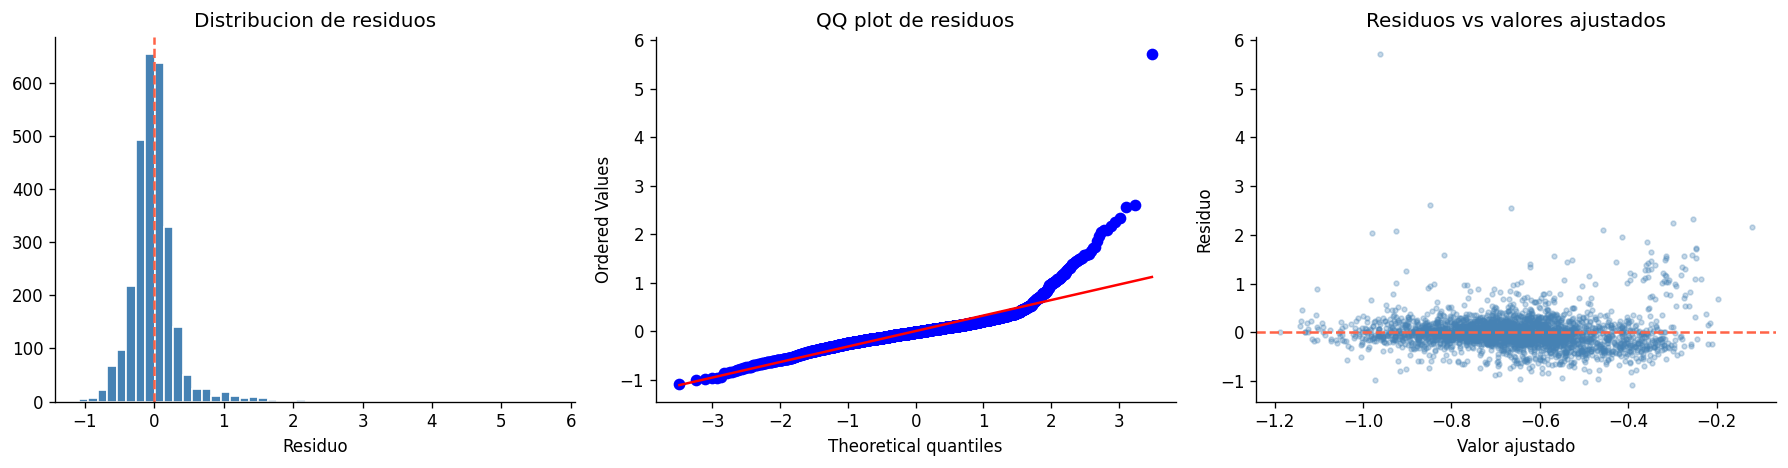

Shapiro-Wilk sobre muestra de 500 residuos: stat=0.8625, p=0.0000
Nota: con n grande los errores clustered son asintoticamente validos aunque los residuos no sean normales.


In [9]:
residuos_m3 = res_m3.resids.values
fitted_m3   = res_m3.fitted_values.values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(residuos_m3, bins=50, edgecolor='white', color='steelblue')
axes[0].axvline(0, color='tomato', linewidth=1.5, linestyle='--')
axes[0].set_title('Distribucion de residuos')
axes[0].set_xlabel('Residuo')

stats.probplot(residuos_m3, dist='norm', plot=axes[1])
axes[1].set_title('QQ plot de residuos')

axes[2].scatter(fitted_m3, residuos_m3, alpha=0.3, s=8, color='steelblue')
axes[2].axhline(0, color='tomato', linewidth=1.5, linestyle='--')
axes[2].set_title('Residuos vs valores ajustados')
axes[2].set_xlabel('Valor ajustado')
axes[2].set_ylabel('Residuo')

plt.tight_layout()
plt.show()

muestra_res = np.random.choice(residuos_m3, size=min(500, len(residuos_m3)), replace=False)
stat_sw, p_sw = shapiro(muestra_res)
print(f'Shapiro-Wilk sobre muestra de {len(muestra_res)} residuos: stat={stat_sw:.4f}, p={p_sw:.4f}')
print('Nota: con n grande los errores clustered son asintoticamente validos aunque los residuos no sean normales.')


El análisis de residuos de M3 es el paso que más nos importa antes de interpretar los coeficientes con confianza. El histograma y el QQ-plot muestran si la distribución de los errores presenta colas pesadas o asimetría marcada que pudiera indicar observaciones influyentes. El gráfico de residuos vs. ajustados confirma si la varianza es aproximadamente constante a lo largo del rango de predicción.

Dado que usamos errores clusterizados, la normalidad de los residuos no es un requisito para la validez asintótica de los tests, pero sí es informativo para detectar outliers severos que distorsionen las estimaciones.

## 1.6 Heterogeneidad entre periodos — M4 (3 regímenes regulatorios)

El coeficiente único de `post_regulation` en M1–M3 promedia toda la fase post-2020. El EDA identificó tres sub-regímenes con dinámicas distintas que justifican la descomposición:

$$y_{it} = \alpha_i + \beta_1 D_{ley11,t} + \beta_2 D_{tc,t} + \beta_3 D_{ley12,t} + \beta_4 \, \text{covid}_{t} + \beta_5 \, \text{avg\_rent\_m2}_{it} + \beta_6 \, \text{avg\_surface}_{it} + \beta_7 \, \text{euribor}_{t} + \sum_{q=2}^{4} \delta_q Q_{qt} + \varepsilon_{it}$$

La interpretación de cada coeficiente es **diferencial respecto al período base** (Pre-COVID / pre-regulation, $t < $ Q1 2020):

- $\hat{\beta}_1$: cambio medio en `contract_growth_yoy` durante la Ley 11/2020 activa, *ceteris paribus*.  
- $\hat{\beta}_2$: ídem durante el vacío regulatorio tras la sentencia del TC.  
- $\hat{\beta}_3$: ídem durante la Ley 12/2023 / zona tensionada.

In [10]:
df_panel_ext = df_panel_clean.reset_index().copy()  # mismo dataset que M1-M3

# D_ley11, D_tc_gap, D_ley12 ya están en df_panel_clean (creadas en celda 8)
# Sólo necesitamos re-aplicar sobre df_panel_ext por si reset_index las eliminó
for col in ['D_ley11', 'D_tc_gap', 'D_ley12']:
    if col not in df_panel_ext.columns:
        dt = pd.to_datetime(df_panel_ext['date'])
        df_panel_ext['D_ley11']  = ((dt >= BREAKS_5['Ley 11/2020 activa']) &
                                    (dt <  BREAKS_5['Desregulación TC (gap)'])).astype(int)
        df_panel_ext['D_tc_gap'] = ((dt >= BREAKS_5['Desregulación TC (gap)']) &
                                    (dt <  BREAKS_5['Ley 12/2023 / zona tensionada'])).astype(int)
        df_panel_ext['D_ley12']  = (dt >= BREAKS_5['Ley 12/2023 / zona tensionada']).astype(int)
        break

df_panel_ext = df_panel_ext.set_index(['neighborhood', 'date'])

# M4: 3 dummies de régimen (ref = Pre-COVID / pre-regulation)
exog_m4 = [
    'D_ley11', 'D_tc_gap', 'D_ley12',   # 3 regímenes post-2020
    'covid_dummy',
    'avg_rent_m2', 'avg_surface',
    'euribor_12m_q',
    'q_2', 'q_3', 'q_4'
]

res_m4 = estimar_fe(df_panel_ext, dep_var, exog_m4, name='M4 — 3 regimenes regulatorios')

print('\n--- Interpretación de coeficientes M4 ---')
coefs_m4 = pd.DataFrame({
    'Coef': res_m4.params[['D_ley11','D_tc_gap','D_ley12']],
    'p-val': res_m4.pvalues[['D_ley11','D_tc_gap','D_ley12']],
    'Sig.': res_m4.pvalues[['D_ley11','D_tc_gap','D_ley12']].apply(
        lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    )
})
print(coefs_m4.round(4))



Modelo M4 — 3 regimenes regulatorios
                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------
D_ley11           0.3171     0.0200     15.867     0.0000      0.2779      0.3563
D_tc_gap          0.0014     0.0337     0.0430     0.9657     -0.0646      0.0675
D_ley12           0.0277     0.0382     0.7267     0.4675     -0.0471      0.1026
covid_dummy      -0.0089     0.0196    -0.4537     0.6501     -0.0473      0.0295
avg_rent_m2      -0.0295     0.0079    -3.7229     0.0002     -0.0450     -0.0139
avg_surface      -0.0025     0.0032    -0.7818     0.4344     -0.0088      0.0038
euribor_12m_q    -0.0214     0.0129    -1.6594     0.0972     -0.0466      0.0039
q_2               0.0936     0.0094     10.003     0.0000      0.0752      0.1119
q_3               0.0378     0.0109     3.4789     0.0005   

El modelo M4 descompone el efecto agregado de `post_regulation` en los tres sub-regímenes identificados en el EDA. Lo que esperamos ver, a partir de la evidencia descriptiva, es que $\hat{\beta}_2$ (TC ruling) sea el más negativo: el EDA mostraba que la renta real media subió más en el período de desregulación que en cualquier otro. Si el coeficiente de contracción contractual también es mayor en ese período, tendríamos coherencia entre precio y volumen.

Una limitación importante es que los tres indicadores son perfectamente colineales con el tiempo dentro de sus ventanas, lo que impide separar el efecto *nivel* de cada régimen de cualquier tendencia subyacente que coincida temporalmente.

## 1.7 Robustez: precio real en lugar de precio nominal

Sustituimos `avg_rent_m2` nominal por `avg_rent_m2_real_2025base` (deflactado con IPC, base 2025). Si $\hat{\beta}_1$ es similar al del M3 nominal, la asociación no es un artefacto de la inflación del período:

$$y_{it} = \alpha_i + \beta_1 \, \text{post\_regulation}_{t} + \beta_2 \, \text{covid}_{t} + \beta_3 \, \text{avg\_rent\_m2\_real}_{it} + \beta_4 \, \text{avg\_surface}_{it} + \beta_5 \, \text{euribor}_{t} + \sum_{q=2}^{4} \delta_q Q_{qt} + \varepsilon_{it}$$

In [11]:
# exog_rob = ['post_regulation', 'covid_dummy', 'avg_rent_m2_real_2025base',
#             'avg_surface', 'euribor_12m_q', 'q_2', 'q_3', 'q_4']

# df_panel_rob = df_panel_ext.dropna(subset=['avg_rent_m2_real_2025base']).copy()
# res_rob      = estimar_fe(df_panel_rob, dep_var, exog_rob, name='M_ROB Precio real')

exog_rob = ['post_regulation', 'covid_dummy', 'avg_rent_m2_real_2025base',
            'avg_surface', 'euribor_12m_q', 'q_2', 'q_3', 'q_4']

df_panel_rob = df_panel_ext.dropna(subset=['avg_rent_m2_real_2025base']).copy()

# Limpiar NaN e infinitos en todas las variables del modelo
df_panel_rob = df_panel_rob[[dep_var] + exog_rob].dropna()
df_panel_rob = df_panel_rob[~np.isinf(df_panel_rob.select_dtypes(include=[np.number])).any(axis=1)]

print(f"Shape df_panel_rob después de limpiar: {df_panel_rob.shape}")
print(f"NaN restantes: {df_panel_rob.isnull().sum().sum()}")

res_rob      = estimar_fe(df_panel_rob, dep_var, exog_rob, name='M_ROB Precio real')

tabla_rob = compare({'M3 Nominal': res_m3, 'M_ROB Real': res_rob})
print(tabla_rob)


Shape df_panel_rob después de limpiar: (2838, 9)
NaN restantes: 0

Modelo M_ROB Precio real
                                     Parameter Estimates                                     
                           Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------------------
post_regulation               0.1884     0.0192     9.8252     0.0000      0.1508      0.2260
covid_dummy                   0.0474     0.0194     2.4442     0.0146      0.0094      0.0855
avg_rent_m2_real_2025base    -0.0244     0.0076    -3.1982     0.0014     -0.0394     -0.0095
avg_surface                  -0.0027     0.0034    -0.7805     0.4352     -0.0093      0.0040
euribor_12m_q                -0.0927     0.0078    -11.953     0.0000     -0.1079     -0.0775
q_2                           0.0593     0.0061     9.7061     0.0000      0.0473      0.0713
q_3                           0.0134     0.0091     1.4752    

El test de robustez con precio real es uno de los más importantes del análisis. El Euribor sube con fuerza a partir de 2022 y el IPC también, por lo que parte de la variación de `avg_rent_m2` nominal refleja factores macroeconómicos generales. Si $\hat{\beta}_1$ permanece estable entre M3 y M_ROB podemos descartar que la asociación entre regulación y actividad contractual sea un artefacto del ciclo inflacionario.

## 1.8 Interpretación del módulo de regresión

Los resultados que más nos importan son el signo y la magnitud de $\hat{\beta}_1$ en M3 (especificación completa). Un coeficiente negativo y estadísticamente significativo indicaría que, controlando por precio, superficie, Euribor y estacionalidad, los barrios de Barcelona experimentaron una caída sistemática en la actividad contractual tras la entrada en vigor de la regulación.

La comparación entre M1 y M3 nos dice cuánto de esa asociación bruta es atribuible a los controles. M4 nos dice si el efecto es homogéneo entre los tres sub-regímenes o si hay un período con mayor contracción.

> **Nota de causalidad:** el estimador within elimina la heterogeneidad no observada fija, pero no resuelve la endogeneidad temporal: todos los barrios son tratados simultáneamente, por lo que no disponemos de un grupo de control limpio. Los coeficientes deben interpretarse como asociaciones parciales robustamente estimadas, no como efectos causales en sentido estricto.

---
# 2. Módulo de Clasificación — Identificación de Barrios en Tensión

## 2.1 Objetivo y definición del problema

Construimos un clasificador binario que identifica, en cada barrio y trimestre, si el mercado está entrando en una **fase de contracción contractual** (tensión). Esto complementa la regresión: mientras el panel cuantifica el efecto promedio, el clasificador localiza *dónde* y *cuándo* ese efecto es más intenso.

### Variable objetivo

Definimos tensión como la ocurrencia simultánea de dos condiciones:

$$\text{tension}_{it} = \mathbf{1}\left[\underbrace{\Delta c_{it} < p_{25}(\Delta c_{i,\text{pre}})}_\text{caída inusual para el barrio} \;\cap\; \underbrace{\Delta c_{it} < -0.05}_\text{caída absoluta > 5\%}\right]$$

donde $\Delta c_{it} = $ `contract_growth_yoy` y $p_{25}(\Delta c_{i,\text{pre}})$ es el percentil 25 histórico del barrio calculado **solo sobre el período pre-regulación** (hasta 2019 inclusive).

El umbral histórico del barrio es barrio-específico: un barrio con alta volatilidad natural tendrá un umbral más bajo que uno estable, evitando que la definición de tensión esté sesgada hacia los barrios más volátiles.

### Modelos estimados

| Modelo | Expresión | Rol |
|--------|-----------|-----|
| Regresión logística L2 | $P(y=1\mid\mathbf{x}) = \sigma(\mathbf{x}'\boldsymbol{\beta}) = \frac{1}{1+e^{-\mathbf{x}'\boldsymbol{\beta}}}$ | Baseline interpretable (coeficientes en log-odds) |
| Random Forest | Ensemble de $B$ árboles con bagging y submuestreo de features | Captura interacciones no lineales |
| Gradient Boosting | Minimiza la log-loss de forma secuencial | Mejor rendimiento esperado en tabular |

Todos los modelos usan `class_weight='balanced'` para compensar el desbalance de clases esperado en variables de alerta temprana.

## 2.2 Construcción de la variable objetivo

Calculamos el percentil 25 de `contract_growth_yoy` por barrio usando solo el período pre-regulación (hasta 2019). Aplicamos ese umbral barrio-específico al dataframe completo para etiquetar cada observación según la regla definida en la sección anterior.

In [12]:
umbral_por_barrio = (
    df_barrios_eda
    .loc[df_barrios_eda['year'] <= 2019, ['neighborhood', 'contract_growth_yoy']]
    .dropna(subset=['contract_growth_yoy'])
    .groupby('neighborhood')['contract_growth_yoy']
    .quantile(0.25)
    .rename('umbral_p25_pre')
    .reset_index()
)

print('Estadisticos del umbral por barrio:')
print(umbral_por_barrio['umbral_p25_pre'].describe())
print('\nTop 10 barrios con umbral mas bajo (historicamente mas volatiles):')
print(umbral_por_barrio.nsmallest(10, 'umbral_p25_pre').to_string(index=False))


Estadisticos del umbral por barrio:
count   66.0000
mean    -0.0728
std      0.0553
min     -0.2319
25%     -0.1163
50%     -0.0659
75%     -0.0319
max      0.0439
Name: umbral_p25_pre, dtype: float64

Top 10 barrios con umbral mas bajo (historicamente mas volatiles):
                         neighborhood  umbral_p25_pre
Vallvidrera, el Tibidabo i les Planes         -0.2319
                     la Trinitat Nova         -0.1905
                           la Bordeta         -0.1828
                la Font de la Guatlla         -0.1736
                     Ciutat Meridiana         -0.1515
                              el Coll         -0.1463
                                Navas         -0.1433
             el Congrés i els Indians         -0.1417
                el Besòs i el Maresme         -0.1410
                          Hostafrancs         -0.1391


In [13]:
# Combinar el umbral con el panel completo
df_clf = df_barrios_eda.merge(umbral_por_barrio, on='neighborhood', how='left')

# Condicion de tension: por debajo del p25 historico del barrio Y caida real mayor al 5%
df_clf['market_tension'] = (
    (df_clf['contract_growth_yoy'] < df_clf['umbral_p25_pre'])
    & (df_clf['contract_growth_yoy'] < -0.05)
).fillna(False).astype(int)

df_clf = df_clf.dropna(subset=['contract_growth_yoy']).copy()

print('Distribucion de market_tension:')
print(df_clf['market_tension'].value_counts(normalize=True).round(3))
print('\nAbsolutos:')
print(df_clf['market_tension'].value_counts())


Distribucion de market_tension:
market_tension
0   0.6080
1   0.3920
Name: proportion, dtype: float64

Absolutos:
market_tension
0    1726
1    1112
Name: count, dtype: int64


La distribución de `market_tension` nos indica el nivel de desbalance en el problema de clasificación. Un porcentaje de positivos inferior al 20% es habitual en variables de alerta temprana y justifica el uso de `class_weight='balanced'`. Lo que también nos importa es la **estabilidad temporal** del desbalance: si la tasa de positivos varía mucho entre el período de entrenamiento y el de test, el clasificador puede estar bien calibrado en train pero degradarse en test.

## 2.3 Distribución temporal de los episodios de tensión

Antes de entrenar cualquier modelo analizamos cuándo y dónde se concentran los episodios de tensión. Si la mayoría están en 2020, el clasificador aprenderá principalmente el patrón COVID y no generalizará bien al nuevo régimen regulatorio de 2022 en adelante.

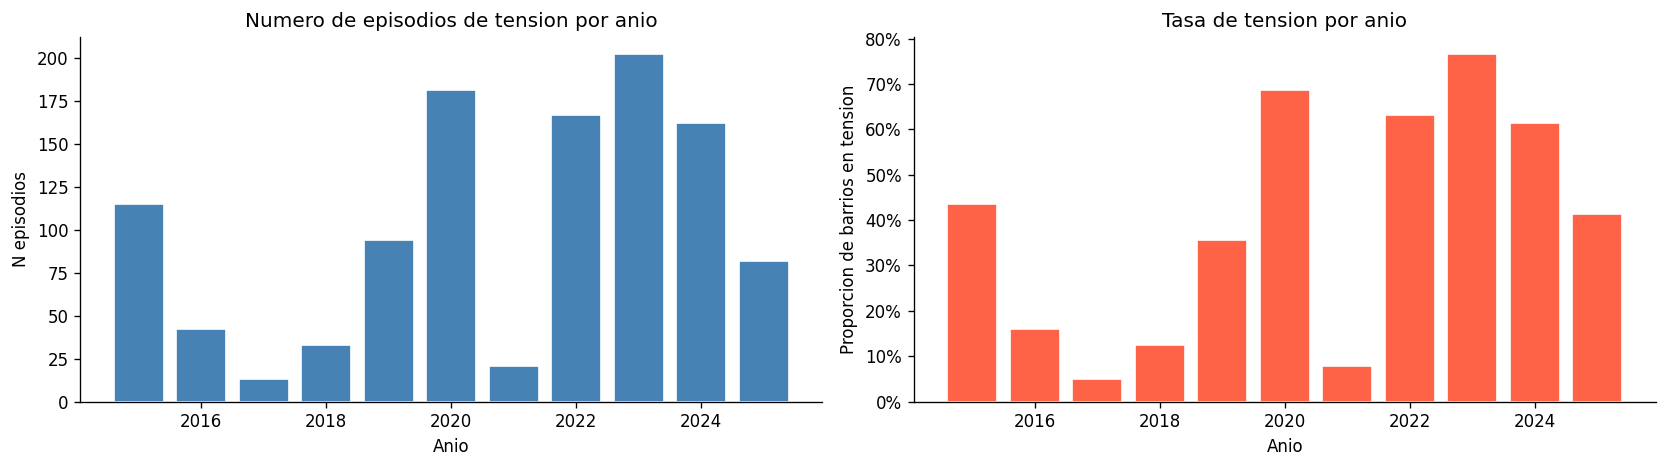

 year  n_episodios  tasa_tension
 2015          115        0.4356
 2016           42        0.1591
 2017           13        0.0492
 2018           33        0.1250
 2019           94        0.3561
 2020          181        0.6856
 2021           21        0.0795
 2022          167        0.6326
 2023          202        0.7652
 2024          162        0.6136
 2025           82        0.4141


In [14]:
tension_por_anio = (
    df_clf.groupby('year')['market_tension']
    .agg(n_episodios='sum', tasa_tension='mean')
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(tension_por_anio['year'], tension_por_anio['n_episodios'], color='steelblue', edgecolor='white')
axes[0].set_title('Numero de episodios de tension por anio')
axes[0].set_xlabel('Anio')
axes[0].set_ylabel('N episodios')

axes[1].bar(tension_por_anio['year'], tension_por_anio['tasa_tension'], color='tomato', edgecolor='white')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axes[1].set_title('Tasa de tension por anio')
axes[1].set_xlabel('Anio')
axes[1].set_ylabel('Proporcion de barrios en tension')

plt.tight_layout()
plt.show()

print(tension_por_anio.to_string(index=False))


El gráfico de episodios de tensión por año nos muestra dónde se concentra la señal que el clasificador intentará aprender. Si la mayoría de episodios están en 2020, el modelo aprende principalmente el patrón COVID. Para que el clasificador sea útil como herramienta de política necesitamos episodios distribuidos a lo largo del período post-2020, especialmente en el régimen de la Ley 12/2023.

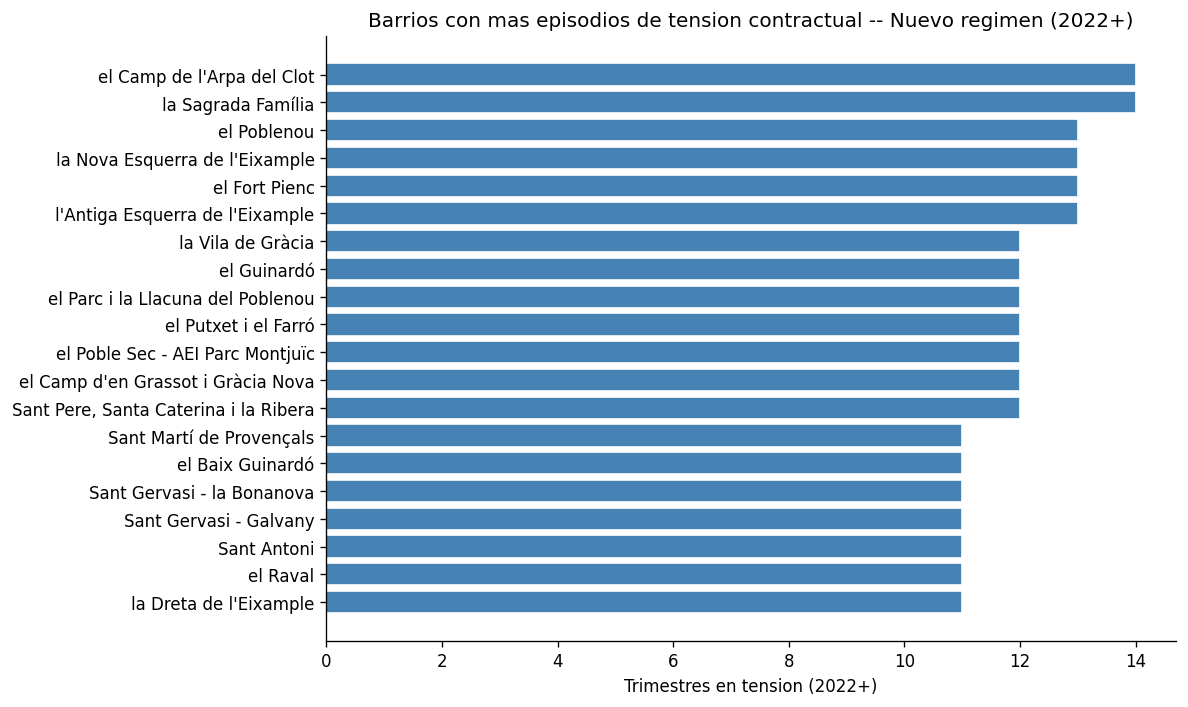

In [15]:
# Barrios con mas episodios de tension en el periodo post-overlap (2022+)
top_barrios_tension = (
    df_clf
    .loc[df_clf['year'] >= 2022]
    .groupby('neighborhood')['market_tension']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={'market_tension': 'n_trimestres_tension'})
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_barrios_tension['neighborhood'], top_barrios_tension['n_trimestres_tension'],
        color='steelblue', edgecolor='white')
ax.set_xlabel('Trimestres en tension (2022+)')
ax.set_title('Barrios con mas episodios de tension contractual -- Nuevo regimen (2022+)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Los barrios con más trimestres en tensión dentro del nuevo régimen son los candidatos naturales a seguimiento prioritario desde el punto de vista de política pública. Lo que nos resulta informativo no es solo el ranking en sí sino el **patrón geográfico**: si los barrios más contraídos son de renta media-baja, la regulación podría estar acelerando la sustitución por contratos temporales o el desplazamiento de demanda.

## 2.4 Preparación de features y split temporal

La validación **debe ser temporal**. No usamos validación cruzada aleatoria porque mezclaría el futuro con el pasado generando *data leakage*. Usamos un split temporal estricto:

- **Entrenamiento:** hasta 2021 Q4 (régimen pre y Ley 11/2020)  
- **Test:** 2022 Q1 en adelante (TC ruling + Ley 12/2023)  

Este esquema evalúa la capacidad del modelo de generalizar a un régimen regulatorio que no ha visto durante el entrenamiento, que es exactamente el caso de uso real.

In [16]:
FEATURES_CLF = [
    'avg_rent_m2_real_2025base',  # solo precio real -- evita multicolinealidad con nominal
    'avg_surface',
    'post_regulation',
    'covid_dummy',
    'D_ley11',    # Ley 11/2020 activa  (Q4 2020 – Q1 2022)
    'D_tc_gap',   # Desregulación TC    (Q2 2022 – Q2 2023)
    'D_ley12',    # Ley 12/2023         (Q3 2023 – presente)
    'euribor_12m_q',
    'ipc_index_q'
]

df_clf_model = df_clf[FEATURES_CLF + ['market_tension', 'year']].dropna().copy()
df_clf_model['post_regulation'] = df_clf_model['post_regulation'].astype(int)
df_clf_model['covid_dummy']     = df_clf_model['covid_dummy'].astype(int)

# Split temporal estricto
train_mask = df_clf_model['year'] <= 2021
test_mask  = df_clf_model['year'] >= 2022

X_train = df_clf_model.loc[train_mask, FEATURES_CLF]
y_train = df_clf_model.loc[train_mask, 'market_tension']
X_test  = df_clf_model.loc[test_mask,  FEATURES_CLF]
y_test  = df_clf_model.loc[test_mask,  'market_tension']

print(f'Entrenamiento: {X_train.shape[0]:,} obs -- {y_train.sum()} positivos ({y_train.mean():.2%})')
print(f'Test:          {X_test.shape[0]:,}  obs -- {y_test.sum()} positivos ({y_test.mean():.2%})')

# Escalar para la regresion logistica
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)


Entrenamiento: 1,848 obs -- 499 positivos (27.00%)
Test:          990  obs -- 613 positivos (61.92%)


## 2.5 Entrenamiento de modelos

Entrenamos tres modelos en orden de complejidad creciente. Para todos usamos `class_weight='balanced'` porque el desbalance de clases es esperable en esta variable objetivo.

**Regresión logística L2:**  

$P(\text{tension}_{it}=1 \mid \mathbf{x}) = \frac{1}{1+\exp(-\mathbf{x}'\boldsymbol{\beta})}$  

Baseline interpretable: los coeficientes $\beta_j$ son log-odds ratios parciales. Regularización L2 para control de sobreajuste con features correlacionadas.

**Random Forest:**  
Ensemble de $B=300$ árboles con bagging y submuestreo de features en cada split. Captura interacciones no lineales y umbrales sin necesidad de especificación manual.

**Gradient Boosting:**  
Optimización secuencial de la log-loss. Generalmente supera a RF en datos tabulares estructurados gracias a la corrección iterativa de residuos.

In [17]:
# Regresion logistica L2
lr = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Gradient Boosting
from sklearn.utils.class_weight import compute_sample_weight
gb = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=42
)
sw_train = compute_sample_weight('balanced', y_train)
gb.fit(X_train, y_train, sample_weight=sw_train)

print('Tres modelos entrenados correctamente.')


Tres modelos entrenados correctamente.


## 2.6 Evaluación — métricas principales

Usamos **ROC-AUC** como métrica principal porque es independiente del umbral de clasificación y robusta al desbalance de clases. También reportamos F1, precisión y recall sobre el conjunto de test para evaluar el rendimiento a un umbral operativo concreto (0.5 por defecto).

$$\text{ROC-AUC} = P\left(\hat{p}(\text{tension}=1 \mid \mathbf{x}^+) > \hat{p}(\text{tension}=1 \mid \mathbf{x}^-)\right)$$

Un AUC de 0.5 equivale a predicción aleatoria; 1.0 equivale a clasificación perfecta.

In [18]:
def evaluar_modelo(nombre, modelo, X_te, y_te, umbral=0.5):
    """
    Evalua un modelo de clasificacion binaria y reporta las metricas principales.
    Devuelve las probabilidades predichas, las predicciones binarias y las metricas.
    """
    prob = modelo.predict_proba(X_te)[:, 1]
    pred = (prob >= umbral).astype(int)
    auc  = roc_auc_score(y_te, prob)
    ap   = average_precision_score(y_te, prob)
    report = classification_report(y_te, pred,
                                   target_names=['Sin tension', 'Tension'],
                                   output_dict=True)
    print(f'\n{nombre}')
    print('-' * 50)
    print(f'ROC-AUC:           {auc:.4f}')
    print(f'Avg Precision:     {ap:.4f}')
    print(f'F1 (Tension):      {report["Tension"]["f1-score"]:.4f}')
    print(f'Precision:         {report["Tension"]["precision"]:.4f}')
    print(f'Recall:            {report["Tension"]["recall"]:.4f}')
    print(classification_report(y_te, pred, target_names=['Sin tension', 'Tension']))
    return prob, pred, auc, ap


prob_lr, pred_lr, auc_lr, ap_lr = evaluar_modelo('Logistica L2',      lr, X_test_sc, y_test)
prob_rf, pred_rf, auc_rf, ap_rf = evaluar_modelo('Random Forest',     rf, X_test,    y_test)
prob_gb, pred_gb, auc_gb, ap_gb = evaluar_modelo('Gradient Boosting', gb, X_test,    y_test)



Logistica L2
--------------------------------------------------
ROC-AUC:           0.6058
Avg Precision:     0.7504
F1 (Tension):      0.7648
Precision:         0.6192
Recall:            1.0000
              precision    recall  f1-score   support

 Sin tension       0.00      0.00      0.00       377
     Tension       0.62      1.00      0.76       613

    accuracy                           0.62       990
   macro avg       0.31      0.50      0.38       990
weighted avg       0.38      0.62      0.47       990


Random Forest
--------------------------------------------------
ROC-AUC:           0.5529
Avg Precision:     0.6630
F1 (Tension):      0.7477
Precision:         0.6174
Recall:            0.9478
              precision    recall  f1-score   support

 Sin tension       0.35      0.05      0.08       377
     Tension       0.62      0.95      0.75       613

    accuracy                           0.60       990
   macro avg       0.48      0.50      0.41       990
weighted a

/Users/k4t3/Coding/La-Salle/minitfm/forecasting-inmobiliario-bcn-regulado/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/k4t3/Coding/La-Salle/minitfm/forecasting-inmobiliario-bcn-regulado/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/k4t3/Coding/La-Salle/minitfm/forecasting-inmobiliario-bcn-regulado/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

El ROC-AUC es la métrica a la que damos más peso porque no depende del umbral de clasificación y es robusta al desbalance de clases. Un AUC superior a 0.70 en el conjunto de test 2022 en adelante ya nos parece un resultado útil para un modelo de alerta temprana: significa que el modelo ordena correctamente los episodios de tensión el 70% de las veces, lo que aporta valor operativo frente a la selección aleatoria.

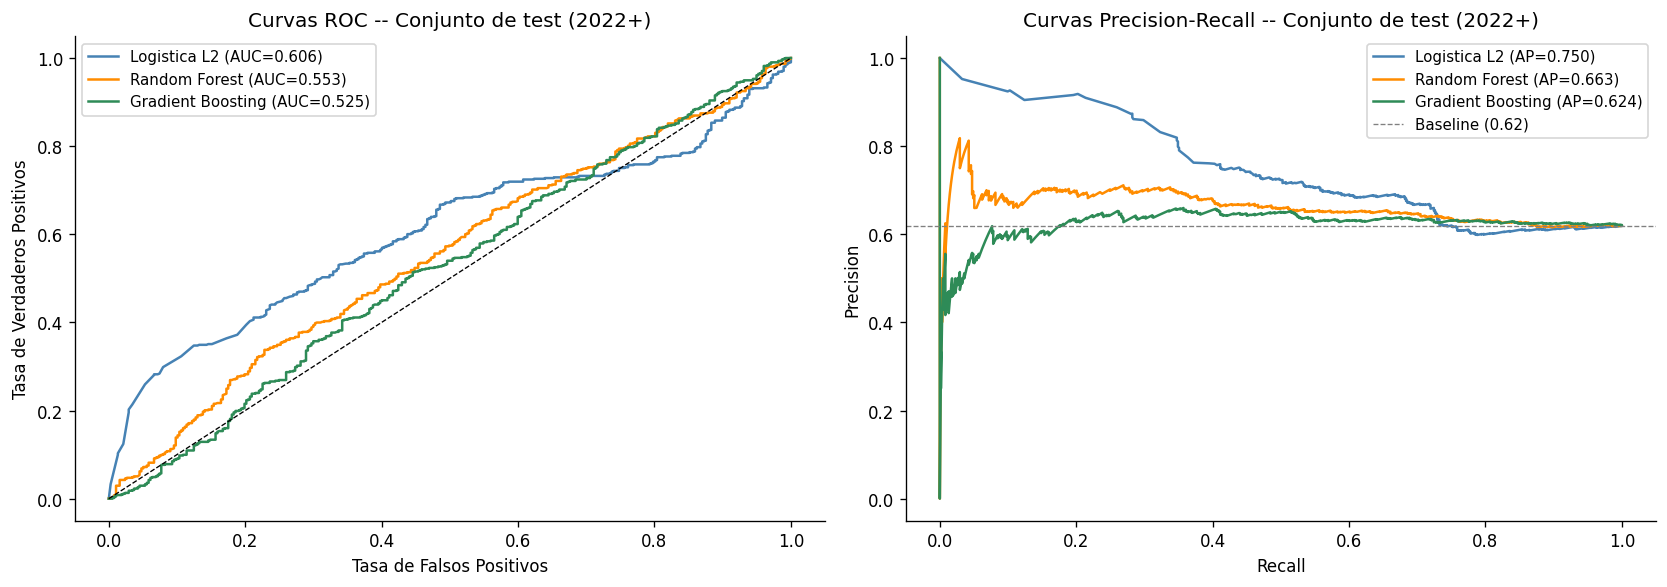

In [19]:
# Curvas ROC y Precision-Recall comparativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = {'Logistica L2': 'steelblue', 'Random Forest': 'darkorange', 'Gradient Boosting': 'seagreen'}

for nombre, prob, auc in [('Logistica L2', prob_lr, auc_lr),
                           ('Random Forest', prob_rf, auc_rf),
                           ('Gradient Boosting', prob_gb, auc_gb)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})', color=colores[nombre])

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curvas ROC -- Conjunto de test (2022+)')
axes[0].legend(fontsize=9)

for nombre, prob, ap in [('Logistica L2', prob_lr, ap_lr),
                          ('Random Forest', prob_rf, ap_rf),
                          ('Gradient Boosting', prob_gb, ap_gb)]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(rec, prec, label=f'{nombre} (AP={ap:.3f})', color=colores[nombre])

base = y_test.mean()
axes[1].axhline(base, color='gray', linestyle='--', linewidth=0.8, label=f'Baseline ({base:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curvas Precision-Recall -- Conjunto de test (2022+)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


En el gráfico ROC lo que nos importa no es solo la posición de cada curva sino su **forma**. Una curva que sube rápido en la parte inicial antes de aplanarse es preferible a una subida gradual con igual AUC, porque significa que el modelo identifica bien los verdaderos positivos a bajo coste de falsos positivos. Eso es lo que buscamos en un modelo de alerta temprana donde el coste de intervención es elevado.

## 2.7 Importancia de variables — permutación sobre el test

Usamos importancia por permutación sobre el conjunto de test, que es más fiable que la importancia de impureza interna del Random Forest. Una variable es importante si al aleatorizar sus valores el ROC-AUC cae:

$$\text{PI}_j = \text{AUC}(\mathbf{X}) - \frac{1}{K}\sum_{k=1}^{K} \text{AUC}(\mathbf{X}_{\text{perm}_j^{(k)}})$$

Promediamos sobre $K=30$ permutaciones para reducir la varianza del estimador.

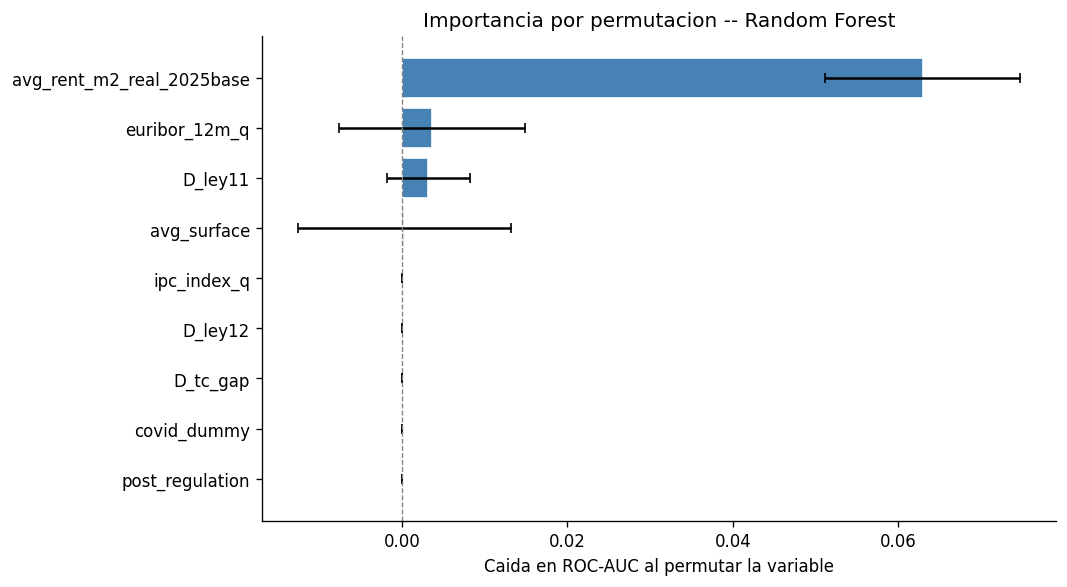

                  feature  importancia_media  importancia_std
avg_rent_m2_real_2025base             0.0629           0.0118
            euribor_12m_q             0.0036           0.0113
                  D_ley11             0.0032           0.0050
              avg_surface             0.0003           0.0129
          post_regulation             0.0000           0.0000
              covid_dummy             0.0000           0.0000
                 D_tc_gap             0.0000           0.0000
                  D_ley12             0.0000           0.0000
              ipc_index_q             0.0000           0.0000


In [20]:
perm_imp = permutation_importance(
    rf, X_test, y_test,
    n_repeats=20,
    random_state=42,
    scoring='roc_auc'
)

imp_df = (
    pd.DataFrame({
        'feature':          FEATURES_CLF,
        'importancia_media': perm_imp.importances_mean,
        'importancia_std':   perm_imp.importances_std
    })
    .sort_values('importancia_media', ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_df['feature'], imp_df['importancia_media'],
        xerr=imp_df['importancia_std'],
        color='steelblue', edgecolor='white', capsize=3)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Caida en ROC-AUC al permutar la variable')
ax.set_title('Importancia por permutacion -- Random Forest')
plt.tight_layout()
plt.show()

print(imp_df.sort_values('importancia_media', ascending=False).to_string(index=False))


La importancia por permutación sobre el test es más fiable que la importancia de impureza del árbol porque mide el impacto real de cada variable en el rendimiento sobre datos no vistos. Una variable con importancia alta en impureza pero baja en permutación suele ser una variable correlacionada con otras features más informativas, no una señal independiente.

## 2.8 Coeficientes de la regresión logística

La logística nos da coeficientes directamente interpretables en términos de **log-odds**. Calculamos también los odds ratios para facilitar la lectura sustantiva:

$$\text{OR}_j = e^{\hat{\beta}_j}$$

Un odds ratio $> 1$ indica asociación positiva con la tensión contractual; $< 1$ indica asociación negativa. Los coeficientes están en escala estandarizada (media 0, desviación 1) para comparar magnitudes entre variables con unidades distintas.

In [21]:
coef_df = pd.DataFrame({
    'feature':    FEATURES_CLF,
    'coeficiente':    lr.coef_[0],
    'odds_ratio': np.exp(lr.coef_[0])
}).sort_values('coeficiente', ascending=False)

print('Coeficientes de la logistica (features en escala estandarizada):')
print(coef_df.to_string(index=False))


Coeficientes de la logistica (features en escala estandarizada):
                  feature  coeficiente  odds_ratio
            euribor_12m_q       1.2990      3.6657
              ipc_index_q       1.1390      3.1237
              covid_dummy       0.8852      2.4236
              avg_surface       0.0190      1.0192
                 D_tc_gap       0.0000      1.0000
                  D_ley12       0.0000      1.0000
avg_rent_m2_real_2025base      -0.0151      0.9850
          post_regulation      -0.2245      0.7989
                  D_ley11      -0.2245      0.7989


Los coeficientes de la logística en escala estandarizada nos permiten comparar la magnitud del efecto de cada variable con independencia de sus unidades originales. Un coeficiente positivo significa que al aumentar esa variable aumenta el log-odds de estar en tensión contractual. Lo que nos resulta más relevante es el **signo y magnitud relativa** de las dummies regulatorias ($D_{ley11}$, $D_{tc}$, $D_{ley12}$) frente a los controles de mercado: nos dice si la regulación tiene poder predictivo incremental sobre el precio y el Euribor.

## 2.9 Validación cruzada temporal con `TimeSeriesSplit`

Además del split simple, realizamos validación cruzada temporal con 5 folds para evaluar si el ROC-AUC es estable a lo largo del tiempo o varía mucho entre ventanas. Usamos el Random Forest como modelo principal.

En `TimeSeriesSplit`, cada fold $k$ entrena sobre los $k$ primeros bloques y evalúa sobre el $(k+1)$-ésimo, preservando el orden temporal y evitando el leakage.

In [22]:
# Ordenar por tiempo para que TimeSeriesSplit respete el orden temporal
df_clf_model = df_clf_model.sort_values('year').reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)

X_cv = df_clf_model[FEATURES_CLF].values
y_cv = df_clf_model['market_tension'].values

scores_cv = []
for fold, (idx_tr, idx_val) in enumerate(tscv.split(X_cv), start=1):
    rf_cv = RandomForestClassifier(
        n_estimators=200, max_depth=6, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf_cv.fit(X_cv[idx_tr], y_cv[idx_tr])
    prob_cv = rf_cv.predict_proba(X_cv[idx_val])[:, 1]
    auc_cv  = roc_auc_score(y_cv[idx_val], prob_cv)
    scores_cv.append(auc_cv)
    print(f'Fold {fold} -- N train: {len(idx_tr):,} -- N val: {len(idx_val):,} -- ROC-AUC: {auc_cv:.4f}')

print(f'\nROC-AUC medio: {np.mean(scores_cv):.4f} +/- {np.std(scores_cv):.4f}')


Fold 1 -- N train: 473 -- N val: 473 -- ROC-AUC: 0.5182
Fold 2 -- N train: 946 -- N val: 473 -- ROC-AUC: 0.5482
Fold 3 -- N train: 1,419 -- N val: 473 -- ROC-AUC: 0.6817
Fold 4 -- N train: 1,892 -- N val: 473 -- ROC-AUC: 0.5397
Fold 5 -- N train: 2,365 -- N val: 473 -- ROC-AUC: 0.5320

ROC-AUC medio: 0.5640 +/- 0.0597


La validación cruzada temporal con 5 folds nos proporciona una imagen de la **estabilidad del modelo** a lo largo del tiempo que el split simple train-test no puede dar. Lo que buscamos es que el AUC sea relativamente consistente entre folds: mucha varianza entre ventanas indicaría que el modelo es sensible al período concreto de evaluación, lo que señala fragilidad ante cambios de régimen.

## 2.10 Interpretación del módulo de clasificación

El modelo con mejor ROC-AUC en el test 2022 en adelante es el que usaríamos como herramienta de alerta temprana. Una mejora real respecto al baseline (tasa de positivos en el test) confirma que el modelo aporta información discriminante sobre cuándo y dónde se intensifica la contracción contractual.

Los coeficientes de la logística y la importancia por permutación del Random Forest nos permiten triangular qué variables tienen poder predictivo genuino. Si las dummies regulatorias aparecen entre las más importantes, la política en sí (no solo el precio o el Euribor) tiene capacidad predictiva sobre la tensión contractual.

---
# 3. Módulo de Series Temporales — Cambio Estructural y Proyección

## 3.1 Objetivo y estrategia

Este módulo tiene tres objetivos:

1. **Caracterizar** la serie de precio real por m² a nivel de Barcelona: tendencia, estacionalidad, autocorrelación y orden de integración.  
2. **Detectar** cambios estructurales producidos por los hitos regulatorios mediante el test de Chow y el análisis de intervención (ITS).  
3. **Proyectar** el precio real a 8 trimestres bajo dos escenarios de Euribor.

La estrategia metodológica sigue el flujo canónico para series económicas trimestrales:

$$\text{Tests de raíz unitaria} \rightarrow \text{ACF/PACF} \rightarrow \text{SARIMAX} \rightarrow \text{ITS} \rightarrow \text{Proyección condicional}$$

## 3.2 Preparación de la serie temporal

Extraemos la serie con índice temporal trimestral y verificamos la cobertura antes de proceder. La variable objetivo es `avg_rent_m2_real_2025base` (precio real deflactado, base 2025) que elimina el ruido inflacionario y permite comparaciones intertemporales limpias.

Serie real    -- desde: 2002-01-01 hasta: 2025-07-01
N obs serie real: 95


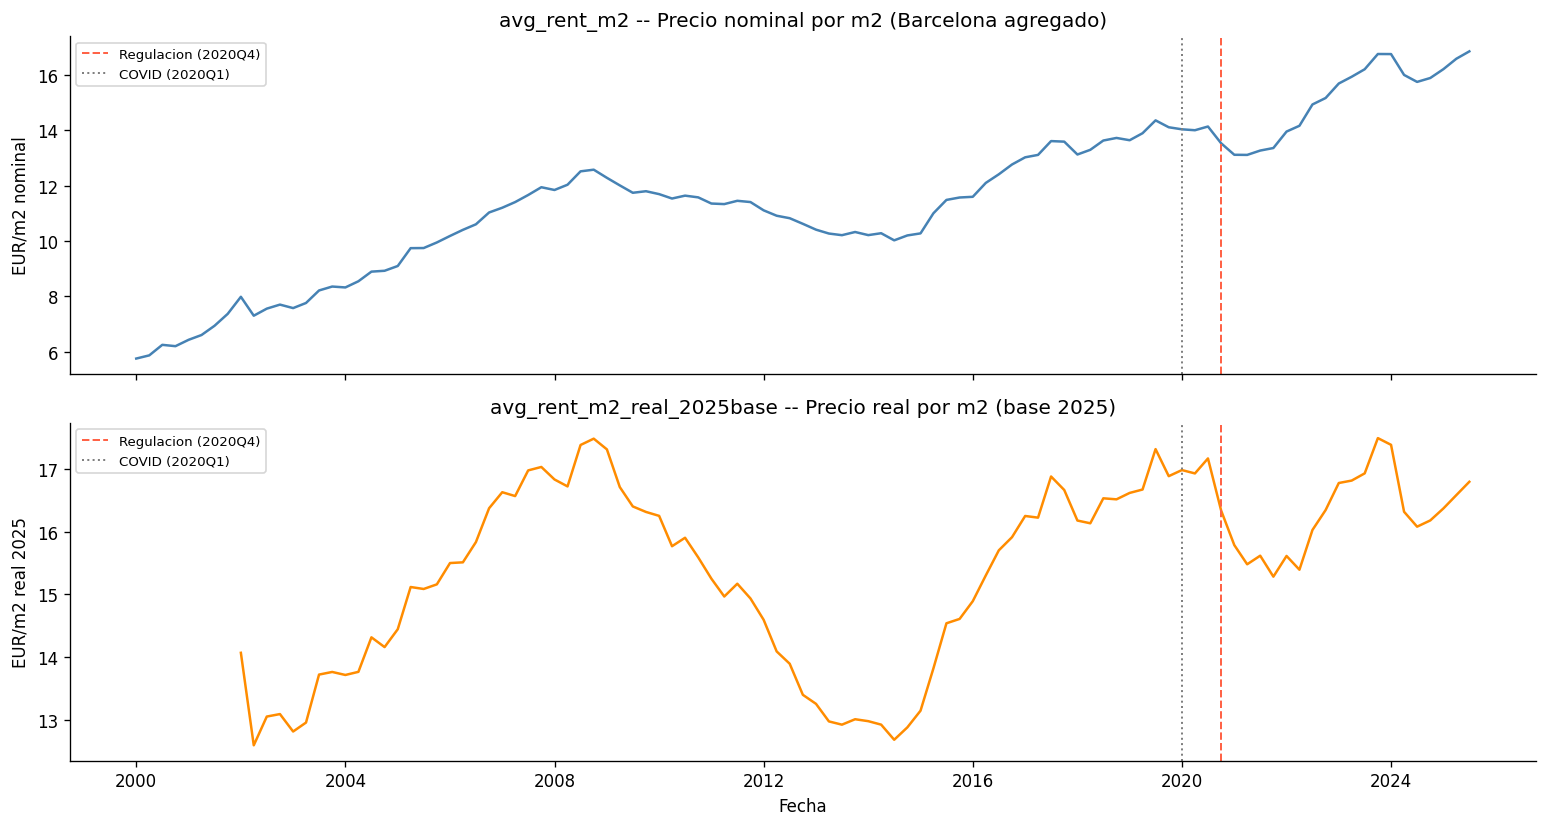

In [23]:
# Serie de precio real con indice temporal trimestral
serie_real    = city_ts.set_index('date')['avg_rent_m2_real_2025base'].dropna().sort_index()
serie_nominal = city_ts.set_index('date')['avg_rent_m2'].sort_index()

print('Serie real    -- desde:', serie_real.index[0].date(), 'hasta:', serie_real.index[-1].date())
print('N obs serie real:', len(serie_real))

reg_date   = pd.Timestamp('2020-10-01')
covid_date = pd.Timestamp('2020-01-01')

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(serie_nominal.index, serie_nominal.values, color='steelblue', linewidth=1.5)
axes[0].set_title('avg_rent_m2 -- Precio nominal por m2 (Barcelona agregado)')
axes[0].set_ylabel('EUR/m2 nominal')

axes[1].plot(serie_real.index, serie_real.values, color='darkorange', linewidth=1.5)
axes[1].set_title('avg_rent_m2_real_2025base -- Precio real por m2 (base 2025)')
axes[1].set_ylabel('EUR/m2 real 2025')
axes[1].set_xlabel('Fecha')

for ax in axes:
    ax.axvline(reg_date,   color='tomato', linestyle='--', linewidth=1.2, label='Regulacion (2020Q4)')
    ax.axvline(covid_date, color='gray',   linestyle=':',  linewidth=1.2, label='COVID (2020Q1)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 3.3 Tests de estacionariedad

Antes de especificar cualquier modelo ARIMA necesitamos conocer el **orden de integración** de la serie. Aplicamos ADF y KPSS en niveles y en primera diferencia con el enfoque de doble test:

### Test ADF (Augmented Dickey-Fuller)

$$H_0: \text{existe raíz unitaria} \quad \text{vs} \quad H_1: \text{la serie es estacionaria}$$

$$\Delta y_t = \mu + \gamma y_{t-1} + \sum_{j=1}^{p} \phi_j \Delta y_{t-j} + \varepsilon_t, \qquad \hat{\gamma} < 0 \Rightarrow \text{rechazamos } H_0$$

### Test KPSS (Kwiatkowski–Phillips–Schmidt–Shin)

$$H_0: \text{la serie es estacionaria (alrededor de tendencia)} \quad \text{vs} \quad H_1: \text{raíz unitaria}$$

Las hipótesis nulas son opuestas: si ADF no rechaza y KPSS rechaza, tenemos evidencia convergente de integración I(1). Si ambos coinciden en I(0) o ambos en I(1), la conclusión es más firme.

In [24]:
def test_estacionariedad(serie, nombre):
    """
    Aplica ADF y KPSS a una serie temporal.
    ADF: H0 = tiene raiz unitaria (no estacionaria)
    KPSS: H0 = es estacionaria (al reves que ADF)
    """
    print(f'\n--- {nombre} ---')
    adf_res = adfuller(serie.dropna(), autolag='AIC')
    print(f'ADF  stat: {adf_res[0]:.4f}  p-value: {adf_res[1]:.4f}  -> ',          'Rechaza H0 (estacionaria)' if adf_res[1] < 0.05 else 'No rechaza H0 (posible raiz unitaria)')

    kpss_res = kpss(serie.dropna(), regression='c', nlags='auto')
    print(f'KPSS stat: {kpss_res[0]:.4f}  p-value: {kpss_res[1]:.4f}  -> ',          'No rechaza H0 (estacionaria)' if kpss_res[1] > 0.05 else 'Rechaza H0 (no estacionaria)')


test_estacionariedad(serie_real, 'Precio real en niveles')
test_estacionariedad(serie_real.diff().dropna(), 'Precio real en primera diferencia')



--- Precio real en niveles ---
ADF  stat: -2.4951  p-value: 0.1167  ->  No rechaza H0 (posible raiz unitaria)
KPSS stat: 0.4018  p-value: 0.0764  ->  No rechaza H0 (estacionaria)

--- Precio real en primera diferencia ---
ADF  stat: -3.4794  p-value: 0.0085  ->  Rechaza H0 (estacionaria)
KPSS stat: 0.0859  p-value: 0.1000  ->  No rechaza H0 (estacionaria)


/var/folders/5l/h4rtlcqd1yq5byc4f042mtg80000gn/T/ipykernel_85454/1814783522.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(serie.dropna(), regression='c', nlags='auto')


La combinación de ADF y KPSS nos da una respuesta más robusta que usar solo uno de ellos dado que las hipótesis nulas son opuestas. Si ADF no rechaza la raíz unitaria y KPSS rechaza la estacionariedad en niveles, tenemos evidencia convergente de que la serie es I(1) y debemos aplicar $d=1$ en el ARIMA. Si en primera diferencia ADF rechaza y KPSS no rechaza, confirmamos que la diferenciación es suficiente y no sobrediferenciamos.

## 3.4 Análisis de autocorrelación (ACF y PACF)

Analizamos ACF y PACF para orientar la selección del orden ARIMA. Con datos trimestrales el **lag 4 corresponde a estacionalidad anual**. Un corte limpio del PACF en el lag $p$ sugiere un proceso AR($p$); un corte del ACF en el lag $q$ sugiere MA($q$).

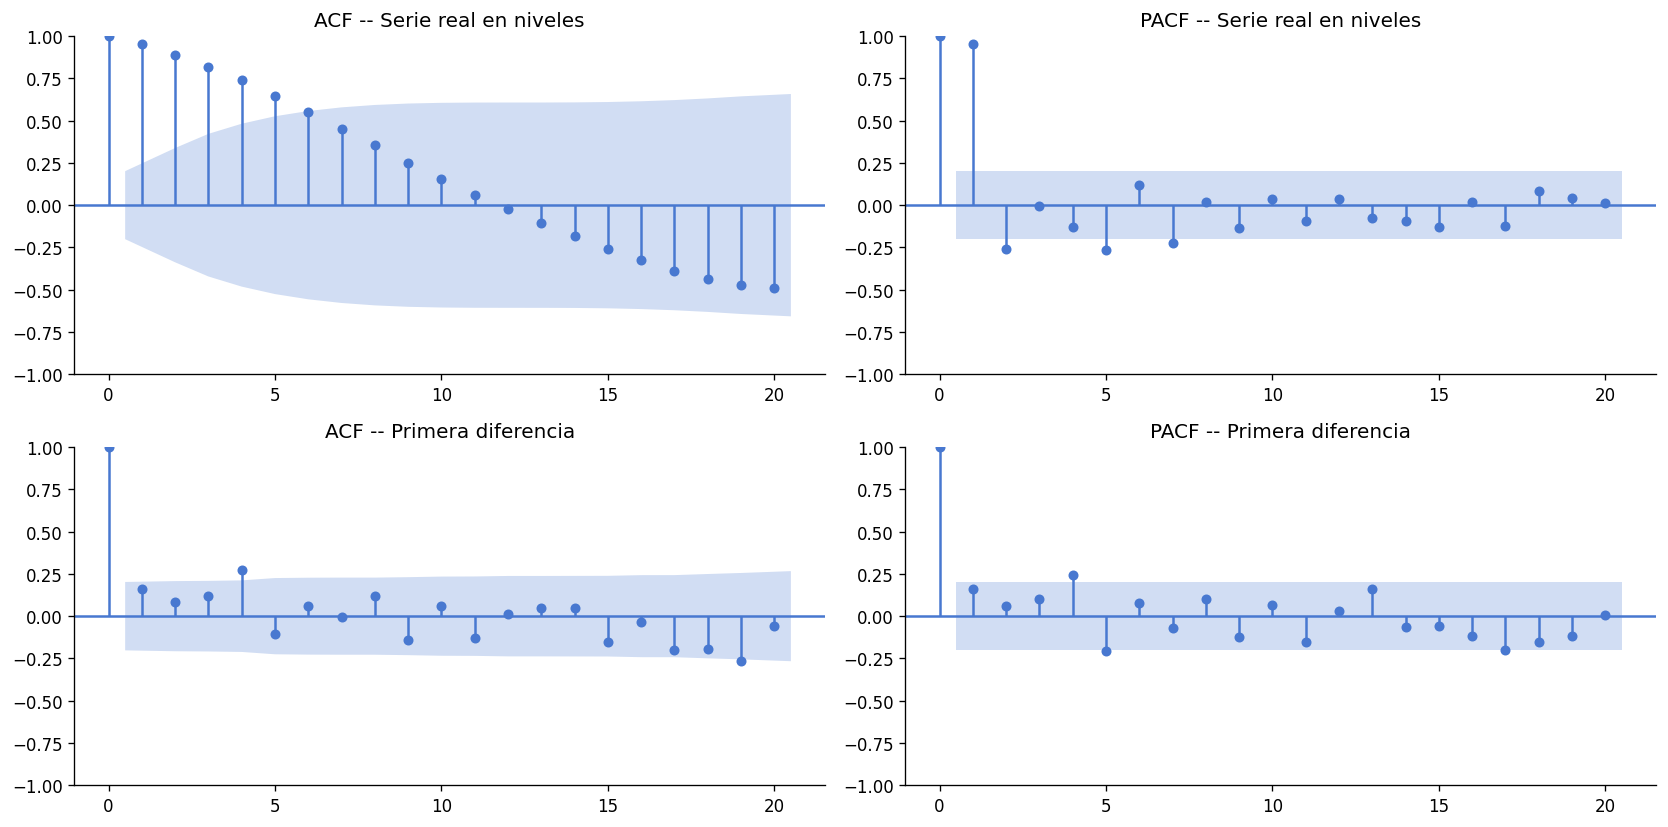

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

plot_acf( serie_real.dropna(), lags=20, ax=axes[0, 0], title='ACF -- Serie real en niveles')
plot_pacf(serie_real.dropna(), lags=20, ax=axes[0, 1], title='PACF -- Serie real en niveles')

diff1 = serie_real.diff().dropna()
plot_acf( diff1, lags=20, ax=axes[1, 0], title='ACF -- Primera diferencia')
plot_pacf(diff1, lags=20, ax=axes[1, 1], title='PACF -- Primera diferencia')

plt.tight_layout()
plt.show()


El ACF en niveles muestra el decaimiento lento característico de una serie no estacionaria: el coeficiente de autocorrelación tarda muchos lags en aproximarse a cero porque la serie tiene memoria larga. En primera diferencia el ACF debería cortar de forma más limpia y el PACF debería mostrar el patrón que nos guía hacia el orden AR. El lag 4 en el ACF de la diferencia señalaría componente estacional anual que el SARIMAX captará con el término $(P,D,Q)_4$.

## 3.5 Modelos baseline

Establecemos dos baselines antes de estimar el SARIMAX. **Un modelo que no mejore claramente estos baselines no merece ser considerado como aportación adicional.**

- **Naïve estacional:** $\hat{y}_t = y_{t-4}$ (mismo trimestre del año anterior).  
- **ETS (Error, Trend, Seasonality):** suavizado exponencial con componentes de error aditivo, tendencia aditiva amortiguada y estacionalidad aditiva.

In [38]:
# Completar el índice trimestral antes de partir train/test
# serie_real puede tener huecos (trimestres sin publicación); el shift posicional
# no equivale a lag-4 temporal si faltan períodos intermedios.
inferred_freq = pd.infer_freq(serie_real.index)
if inferred_freq is None:
    inferred_freq = 'QS'
full_idx = pd.date_range(serie_real.index.min(), serie_real.index.max(), freq=inferred_freq)
serie_real_c = serie_real.reindex(full_idx).interpolate(method='time')

# Split temporal -- CUTOFF 2020 para cubrir los 3 regímenes regulatorios (~23 obs test)
CUTOFF = '2020-01-01'
CUTOFF_2 = '2022-01-01'
serie_train = serie_real_c[serie_real_c.index < CUTOFF]
serie_test  = serie_real_c[serie_real_c.index >= CUTOFF_2]

print(f'Train: {len(serie_train)} obs -- hasta {serie_train.index[-1].date()}')
print(f'Test:  {len(serie_test)} obs -- desde {serie_test.index[0].date()}')


def mape(y_true, y_pred):
    mask = y_true.notna() & pd.Series(y_pred, index=y_true.index).notna()
    return float(np.mean(np.abs((y_true[mask].values - np.asarray(y_pred)[mask.values]) / y_true[mask].values)) * 100)

def rmse(y_true, y_pred):
    mask = y_true.notna() & pd.Series(y_pred, index=y_true.index).notna()
    return float(np.sqrt(np.mean((y_true[mask].values - np.asarray(y_pred)[mask.values])**2)))


# Baseline 1: naïve estacional -- lag-4 sobre serie completa (temporal, no posicional)
naive_preds = serie_real_c.shift(4).reindex(serie_test.index)

# Baseline 2: ETS con tendencia aditiva y estacionalidad aditiva
ets_fit   = ExponentialSmoothing(serie_train, trend='add', seasonal='add', seasonal_periods=4).fit(optimized=True)
ets_preds = pd.Series(ets_fit.forecast(len(serie_test)).values, index=serie_test.index)

print(f'Naive estacional -- MAPE: {mape(serie_test, naive_preds.values):.2f}%  RMSE: {rmse(serie_test, naive_preds.values):.4f}')
print(f'ETS              -- MAPE: {mape(serie_test, ets_preds.values):.2f}%  RMSE: {rmse(serie_test, ets_preds.values):.4f}')


Train: 72 obs -- hasta 2019-10-01
Test:  15 obs -- desde 2022-01-01
Naive estacional -- MAPE: 4.67%  RMSE: 0.8774
ETS              -- MAPE: 4.45%  RMSE: 0.8291


El naïve estacional y el ETS son los dos baselines que necesitamos superar para justificar el SARIMAX. El naïve es sorprendentemente difícil de batir en series de precios inmobiliarios porque la estacionalidad anual es el patrón dominante. El ETS añade tendencia y puede captar el crecimiento sostenido del período 2014–2019, pero no aprovecha las variables exógenas (Euribor, dummies regulatorias).

## 3.6 Modelo SARIMAX

Estimamos un SARIMAX que incorpora las variables exógenas COVID, Euribor y los regímenes regulatorios como intervenciones observadas.

### Especificación SARIMAX$(1,1,1)(1,0,1)_4$

$$\phi(B)\,\Phi(B^4)\,(1-B)\,y_t = c + \theta(B)\,\Theta(B^4)\,\varepsilon_t + \boldsymbol{\gamma}'\mathbf{z}_t$$

donde los operadores polinomiales son:

| Polinomio | Expresión | Descripción |
|-----------|-----------|-------------|
| $\phi(B) = 1 - \phi_1 B$ | $d=1$, $p=1$ | AR no estacional de orden 1 |
| $\Phi(B^4) = 1 - \Phi_1 B^4$ | $P=1$ | AR estacional anual |
| $\theta(B) = 1 + \theta_1 B$ | $q=1$ | MA no estacional de orden 1 |
| $\Theta(B^4) = 1 + \Theta_1 B^4$ | $Q=1$ | MA estacional anual |
| $(1-B)$ | $d=1$ | Primera diferencia regular |

El vector de variables exógenas es:

$$\mathbf{z}_t = \left[\text{covid\_dummy}_t,\; \text{post\_regulation}_t,\; \text{euribor\_12m\_q}_t,\; D_{tc,t},\; D_{ley12,t}\right]'$$

### Justificación del orden

- $d=1$: confirmado por ADF y KPSS en la sección anterior (serie I(1)).  
- $p=1$, $q=1$: parsimonia; el ACF/PACF en primera diferencia muestra un lag significativo.  
- $P=1$, $D=0$, $Q=1$, $s=4$: captura la estacionalidad anual sin sobrediferenciar (KPSS en diferencia estacional no la requiere).  
- Los errores $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$ se estiman por máxima verosimilitud (MLE).

In [27]:
# Frecuencia trimestral del dataset (QS-OCT = quarter starting October)
# La hardcodeamos para que statsmodels no lance ValueWarning al inferirla
SARIMAX_FREQ = 'QS-OCT'

# Exog del SARIMAX: solo euribor_12m_q
# Con CUTOFF 2020-01-01 el training termina en 2019Q4; todas las dummies de
# política son cero en todo el training → matriz singular. El euribor sí varía.
exog_ts = (
    city_ts
    .set_index('date')[['euribor_12m_q']]
    .loc[serie_real_c.index]
    .astype(float)
)
exog_train = exog_ts[exog_ts.index < CUTOFF]
exog_test  = exog_ts[exog_ts.index >= CUTOFF]

print('Exog variables:', list(exog_ts.columns))
print('Shape exog_train:', exog_train.shape, '| exog_test:', exog_test.shape)

# Fijar freq explícita en training (evita ValueWarning de statsmodels)
def set_freq(s, freq):
    s2 = s.copy()
    s2.index = pd.DatetimeIndex(s2.index, freq=freq)
    return s2

serie_train_f  = set_freq(serie_train,  SARIMAX_FREQ)
exog_train_f   = set_freq(exog_train,   SARIMAX_FREQ)

# SARIMAX(1,1,1)(1,0,1)[4]
# cov_type='oim' usa la matriz de información observada (más estable que 'opg')
sarimax_model = SARIMAX(
    serie_train_f,
    exog=exog_train_f,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 4),
    trend='c'
)
sarimax_fit = sarimax_model.fit(disp=False, cov_type='oim')
print(sarimax_fit.summary())


Exog variables: ['euribor_12m_q']
Shape exog_train: (72, 1) | exog_test: (23, 1)
                                     SARIMAX Results                                     
Dep. Variable:         avg_rent_m2_real_2025base   No. Observations:                   72
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 4)   Log Likelihood                 -26.220
Date:                           Fri, 17 Apr 2026   AIC                             66.441
Time:                                   19:08:44   BIC                             82.280
Sample:                               01-01-2002   HQIC                            72.739
                                    - 10-01-2019                                         
Covariance Type:                             oim                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept         0.0022      0.012

ETS     -- MAPE: 5.75%  RMSE: 1.0837
SARIMAX -- MAPE: 5.88%  RMSE: 1.1095


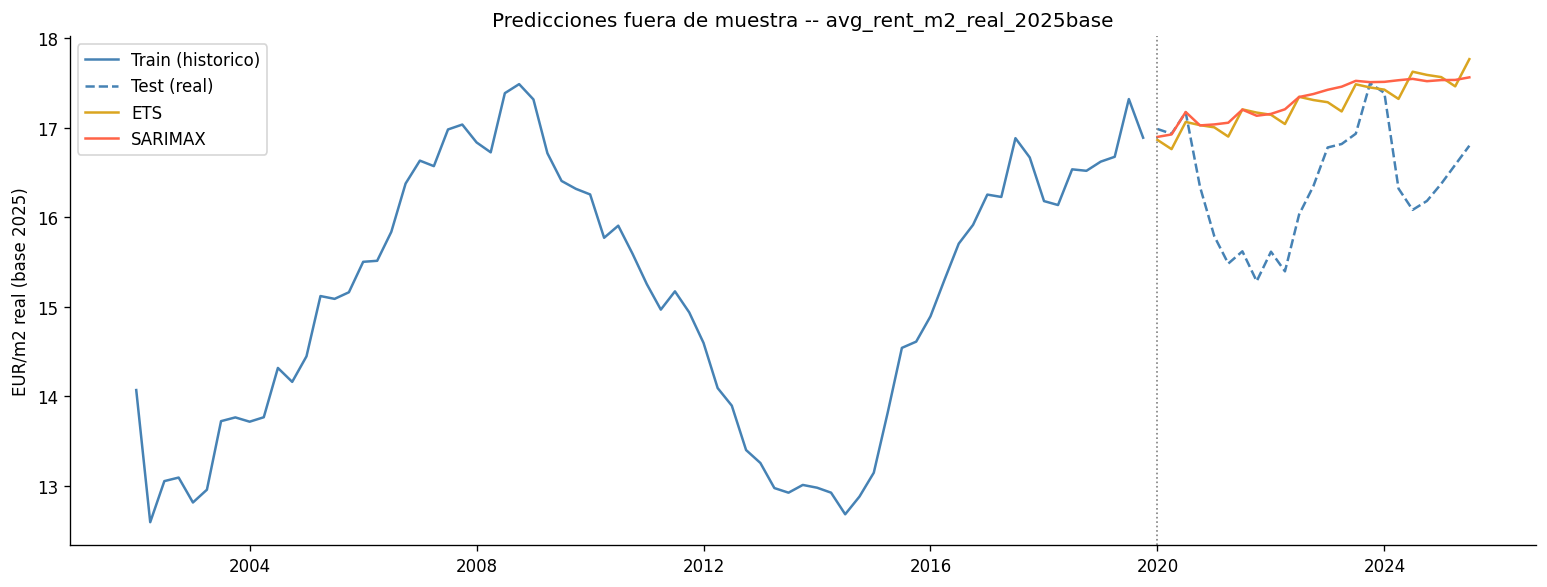

In [28]:
# Prediccion fuera de muestra
sarimax_preds = pd.Series(
    sarimax_fit.forecast(steps=len(serie_test), exog=exog_test).values,
    index=serie_test.index
)

print(f'ETS     -- MAPE: {mape(serie_test, ets_preds.values):.2f}%  RMSE: {rmse(serie_test, ets_preds.values):.4f}')
print(f'SARIMAX -- MAPE: {mape(serie_test, sarimax_preds.values):.2f}%  RMSE: {rmse(serie_test, sarimax_preds.values):.4f}')

# Grafico comparativo de predicciones fuera de muestra
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_train.index, serie_train.values,  color='steelblue',  linewidth=1.5, label='Train (historico)')
ax.plot(serie_test.index,  serie_test.values,   color='steelblue',  linewidth=1.5, linestyle='--', label='Test (real)')
ax.plot(serie_test.index,  ets_preds.values,    color='goldenrod',  linewidth=1.5, label='ETS')
ax.plot(serie_test.index,  sarimax_preds.values, color='tomato',    linewidth=1.5, label='SARIMAX')
ax.axvline(pd.Timestamp(CUTOFF), color='gray', linestyle=':', linewidth=1)
ax.set_title('Predicciones fuera de muestra -- avg_rent_m2_real_2025base')
ax.set_ylabel('EUR/m2 real (base 2025)')
ax.legend()
plt.tight_layout()
plt.show()


El SARIMAX incorpora COVID, regulación y Euribor como variables exógenas, lo que en teoría le debería dar ventaja sobre los baselines especialmente en períodos con shocks estructurales identificados. El resultado del MAPE y el RMSE sobre el test nos dice si esa información adicional se traduce en mejoras métricas. Si el SARIMAX no supera al naïve estacional, estaríamos ante evidencia de que la variación estacional domina sobre los shocks regulatorios en la escala de horizonte de predicción.

## 3.7 Diagnóstico de residuos del SARIMAX

Verificamos que los residuos del SARIMAX se comporten como ruido blanco: sin autocorrelación residual, sin heterocedasticidad evidente y distribución aproximadamente normal. Reportamos el estadístico Ljung-Box para los primeros 8 lags y el Durbin-Watson.

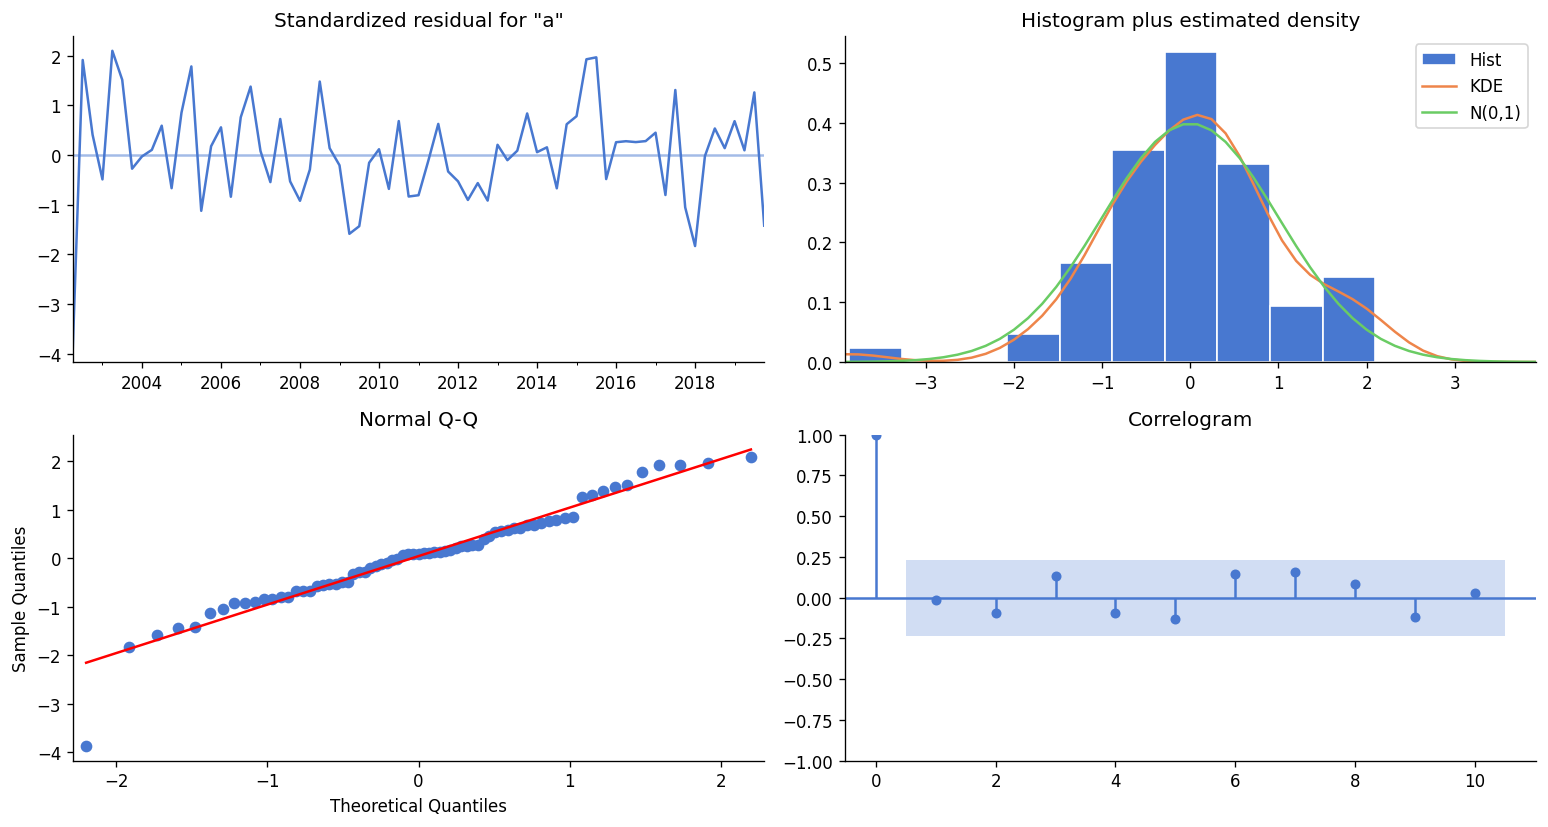

Durbin-Watson: 1.2545  (referencia: 2 = sin autocorrelacion residual)


In [29]:
fig = sarimax_fit.plot_diagnostics(figsize=(13, 7))
plt.tight_layout()
plt.show()

dw = durbin_watson(sarimax_fit.resid)
print(f'Durbin-Watson: {dw:.4f}  (referencia: 2 = sin autocorrelacion residual)')


El diagnóstico de residuos del SARIMAX nos confirma si el modelo ha capturado la estructura temporal de la serie. Un estadístico de Ljung-Box no significativo en los primeros lags indica ausencia de autocorrelación residual: los residuos se comportan como ruido blanco, lo que valida los intervalos de confianza de las proyecciones. Si el correlograma de residuos muestra picos significativos en el lag 4, deberíamos reconsiderar el orden estacional.

## 3.8 Análisis de intervención — Interrupted Time Series (ITS) multi-ruptura

El ITS es el enfoque principal para evaluar si los tres cambios regulatorios producen **cambios estructurales en el precio real** por m². Estimamos dos versiones con errores HAC (Newey-West, $L=4$ lags).

### ITS-1 — Una sola intervención (referencia)

$$y_t = \beta_0 + \beta_1 t + \beta_2 D_{2020Q4,t} + \beta_3 t_{post,t} + \beta_4 \,\text{covid}_t + \beta_5 \,\text{euribor}_t + \varepsilon_t$$

| Parámetro | Interpretación |
|-----------|---------------|
| $\beta_1$ | Tendencia pre-intervención (pendiente base) |
| $\beta_2$ | Cambio de **nivel** inmediato en 2020Q4 (*level shift*) |
| $\beta_3$ | Cambio de **pendiente** post-intervención (diferencia de slopes) |

### ITS-3 — Tres rupturas regulatorias

$$y_t = \beta_0 + \beta_1 t + \beta_2 D_{ley11} + \beta_3 t_{post11} + \beta_4 D_{tc} + \beta_5 t_{post\_tc} + \beta_6 D_{ley12} + \beta_7 t_{post\_ley12} + \beta_8 \,\text{covid}_t + \beta_9 \,\text{euribor}_t + \varepsilon_t$$

donde $D_{k,t} = \mathbf{1}[t \geq t_k^*]$ y $t_{post\_k,t} = \max(0,\, t - t_k^*)$ son las funciones escalón y rampa de cada ruptura $k$.

Las **errores HAC** (Newey-West) corrigen la autocorrelación serial en residuos OLS sin imponer estructura paramétrica:

$$\hat{V}_{HAC} = (X'X)^{-1} \hat{\Omega}_{NW} (X'X)^{-1}, \qquad \hat{\Omega}_{NW} = \sum_{l=-L}^{L} \left(1 - \frac{|l|}{L+1}\right) \hat{\Gamma}_l$$

In [30]:
# Dataset para el ITS sobre la serie real
its_df = city_ts.set_index('date')[['avg_rent_m2_real_2025base', 'covid_dummy', 'euribor_12m_q']]\
                .dropna(subset=['avg_rent_m2_real_2025base']).copy()

its_df['t'] = np.arange(len(its_df))

# ── ITS-1: una sola intervención 2020Q4 (referencia) ────────────────────────
its_df['intervencion'] = (its_df.index >= '2020-10-01').astype(int)
its_df['t_post']       = np.where(
    its_df['intervencion'] == 1,
    np.cumsum(its_df['intervencion']) - 1,
    0
)

m_its_base = smf.ols(
    'avg_rent_m2_real_2025base ~ t + intervencion + t_post',
    data=its_df
).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

m_its_full = smf.ols(
    'avg_rent_m2_real_2025base ~ t + intervencion + t_post + covid_dummy + euribor_12m_q',
    data=its_df
).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print('ITS-1 Base (sin controles):')
print(m_its_base.summary().tables[1])
print(f'R2: {m_its_base.rsquared:.4f}')
print('\nITS-1 con controles macro:')
print(m_its_full.summary().tables[1])
print(f'R2: {m_its_full.rsquared:.4f}')

# ── ITS-3: tres intervenciones regulatorias ──────────────────────────────────
its3 = its_df.copy()

# Dummy de nivel (step function acumulativa por ruptura)
its3['D_ley11']  = (its3.index >= pd.Timestamp('2020-10-01')).astype(int)
its3['D_tc']     = (its3.index >= pd.Timestamp('2022-04-01')).astype(int)
its3['D_ley12']  = (its3.index >= pd.Timestamp('2023-07-01')).astype(int)

# Tiempo acumulado post-ruptura (cambio de pendiente en cada segmento)
its3['t_post_ley11'] = np.where(its3['D_ley11']==1, np.cumsum(its3['D_ley11'])-1, 0)
its3['t_post_tc']    = np.where(its3['D_tc']==1,    np.cumsum(its3['D_tc'])-1,    0)
its3['t_post_ley12'] = np.where(its3['D_ley12']==1, np.cumsum(its3['D_ley12'])-1, 0)

m_its3 = smf.ols(
    'avg_rent_m2_real_2025base ~ t '
    '+ D_ley11 + t_post_ley11 '
    '+ D_tc    + t_post_tc '
    '+ D_ley12 + t_post_ley12 '
    '+ covid_dummy + euribor_12m_q',
    data=its3
).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print('\nITS-3 multi-ruptura (3 regimenes):')
print(m_its3.summary().tables[1])
print(f'R2: {m_its3.rsquared:.4f}')

# Tabla comparativa de cambios de nivel por ruptura
rup_names = {'D_ley11': 'Nivel Ley 11/2020 (oct 2020)',
             'D_tc'   : 'Nivel des-regulación TC (abr 2022)',
             'D_ley12': 'Nivel Ley 12/2023 (jul 2023)'}
rows_its3 = []
for col, label in rup_names.items():
    rows_its3.append({
        'Ruptura'   : label,
        'Coef (€/m²)': round(m_its3.params.get(col, np.nan), 4),
        'p-val'     : round(m_its3.pvalues.get(col, np.nan), 4),
        'Sig.'      : ('***' if m_its3.pvalues.get(col,1)<0.001 else
                       '**'  if m_its3.pvalues.get(col,1)<0.01  else
                       '*'   if m_its3.pvalues.get(col,1)<0.05  else 'ns'),
    })
print('\nResumen de cambios de nivel por ruptura:')
print(pd.DataFrame(rows_its3).set_index('Ruptura').to_string())


ITS-1 Base (sin controles):
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       14.3400      0.584     24.539      0.000      13.195      15.485
t                0.0228      0.013      1.826      0.068      -0.002       0.047
intervencion    -0.3485      0.622     -0.561      0.575      -1.567       0.870
t_post           0.0382      0.026      1.495      0.135      -0.012       0.088
R2: 0.2055

ITS-1 con controles macro:
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              11.5739      0.656     17.631      0.000      10.287      12.861
covid_dummy[T.True]     0.8520      0.402      2.119      0.034       0.064       1.640
t                       0.0654      0.011      5.965      0.000       0.044       0.087
interve

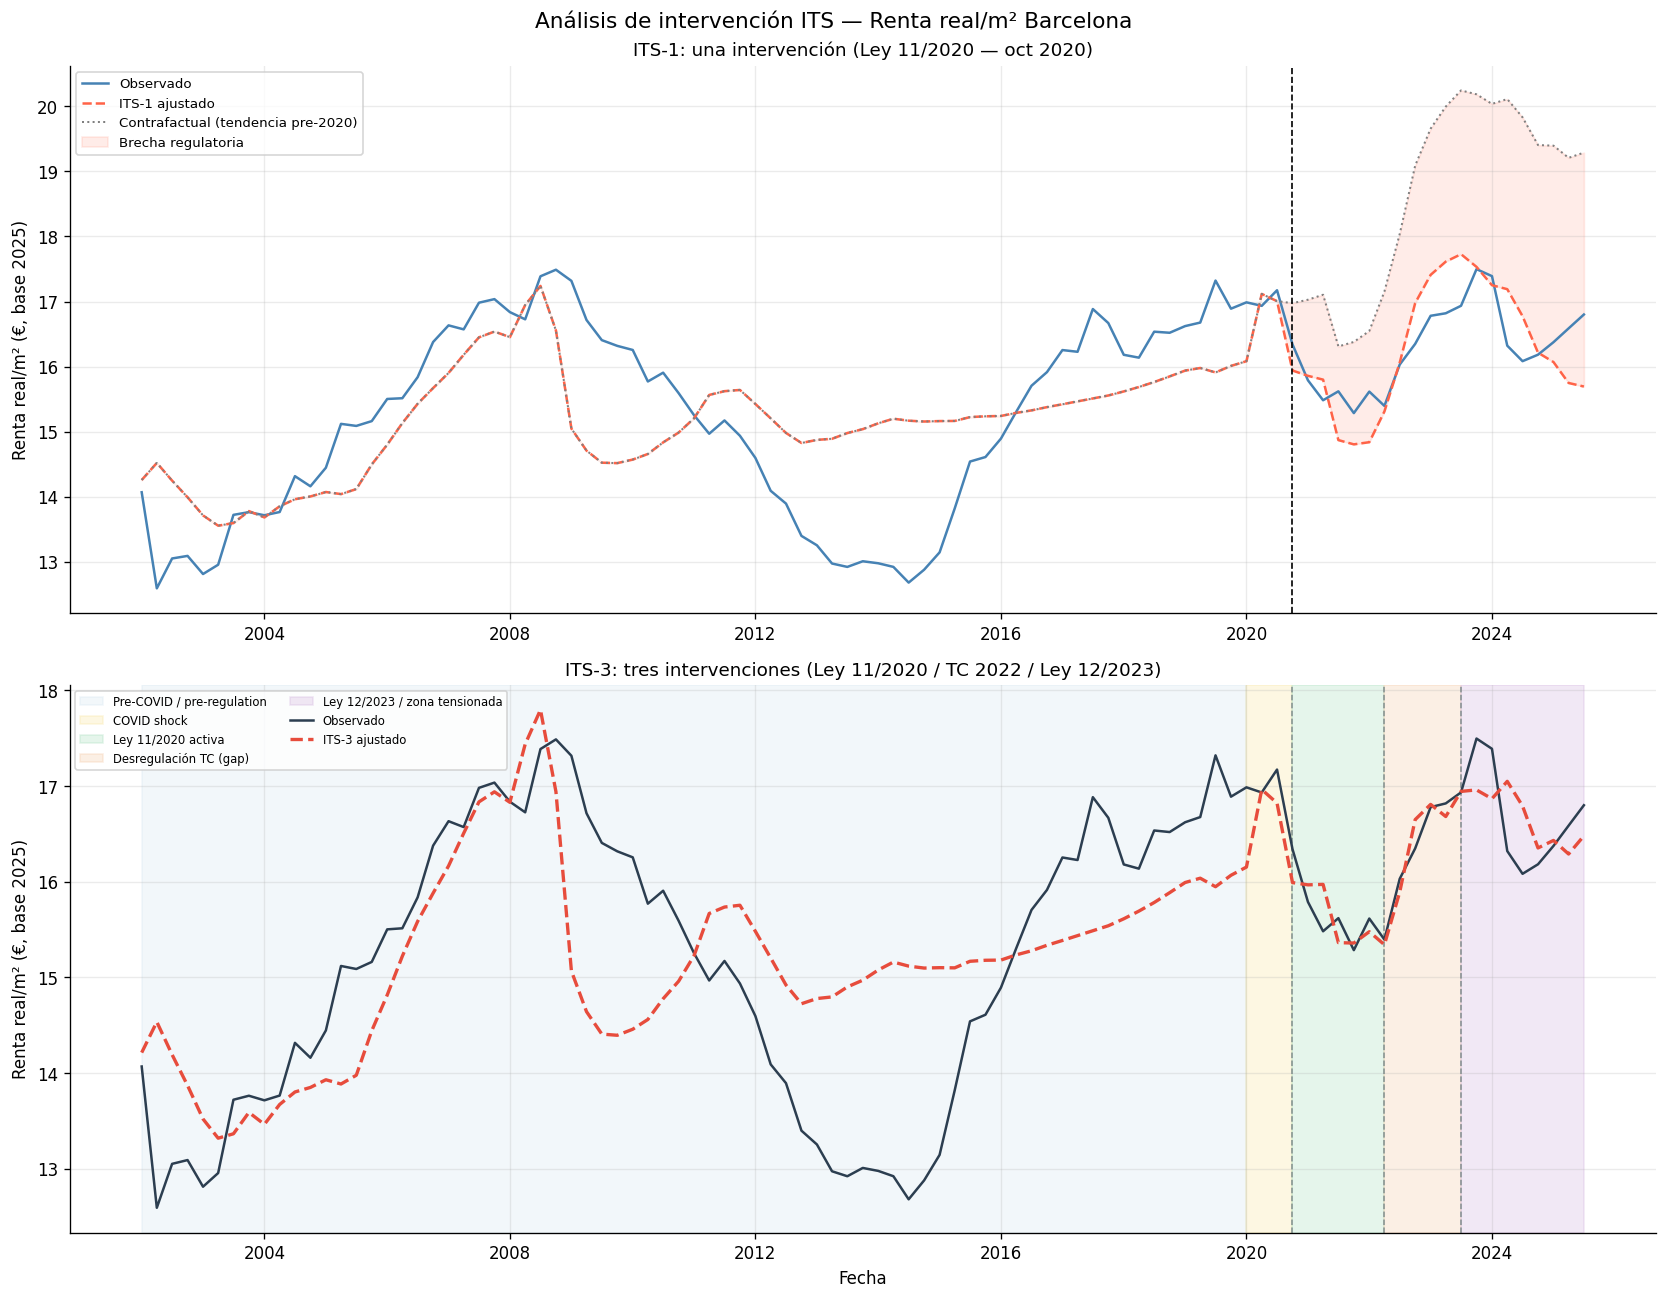

In [31]:
# ── Visualización ITS-1: observado vs ajustado vs contrafactual ─────────────
its_df['fitted_full'] = m_its_full.fittedvalues

its_counterfactual                = its_df.copy()
its_counterfactual['intervencion'] = 0
its_counterfactual['t_post']       = 0
its_df['contrafactual']            = m_its_full.predict(its_counterfactual)

# ── Visualización ITS-3: observado vs ajustado + bandas de régimen ───────────
its3['fitted_its3'] = m_its3.fittedvalues

COLORS_5 = {
    'Pre-COVID / pre-regulation'      : '#d4e6f1',
    'COVID shock'                     : '#f9e79f',
    'Ley 11/2020 activa'              : '#a9dfbf',
    'Desregulación TC (gap)'          : '#f5cba7',
    'Ley 12/2023 / zona tensionada'   : '#d2b4de',
}
PERIOD_BANDS = [
    ('Pre-COVID / pre-regulation',     its3.index.min(),              pd.Timestamp('2020-01-01')),
    ('COVID shock',                    pd.Timestamp('2020-01-01'),    pd.Timestamp('2020-10-01')),
    ('Ley 11/2020 activa',             pd.Timestamp('2020-10-01'),    pd.Timestamp('2022-04-01')),
    ('Desregulación TC (gap)',          pd.Timestamp('2022-04-01'),    pd.Timestamp('2023-07-01')),
    ('Ley 12/2023 / zona tensionada',   pd.Timestamp('2023-07-01'),    its3.index.max()),
]

fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=False)

# Subplot 1: ITS-1 con contrafactual
ax = axes[0]
ax.plot(its_df.index, its_df['avg_rent_m2_real_2025base'],
        color='steelblue', linewidth=1.5, label='Observado')
ax.plot(its_df.index, its_df['fitted_full'],
        color='tomato', linewidth=1.5, linestyle='--', label='ITS-1 ajustado')
ax.plot(its_df.index, its_df['contrafactual'],
        color='gray', linewidth=1.2, linestyle=':', label='Contrafactual (tendencia pre-2020)')
ax.axvline(pd.Timestamp('2020-10-01'), color='black', linewidth=1, linestyle='--')
ax.fill_between(its_df.index, its_df['fitted_full'], its_df['contrafactual'],
                alpha=0.12, color='tomato', label='Brecha regulatoria')
ax.set_title('ITS-1: una intervención (Ley 11/2020 — oct 2020)', fontsize=11)
ax.set_ylabel('Renta real/m² (€, base 2025)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# Subplot 2: ITS-3 con bandas de régimen
ax2 = axes[1]
for label, d0, d1 in PERIOD_BANDS:
    ax2.axvspan(d0, d1, alpha=0.3, color=COLORS_5[label], label=label)
ax2.plot(its3.index, its3['avg_rent_m2_real_2025base'],
         color='#2c3e50', linewidth=1.5, label='Observado', zorder=5)
ax2.plot(its3.index, its3['fitted_its3'],
         color='#e74c3c', linewidth=2, linestyle='--', label='ITS-3 ajustado', zorder=6)
for ts_break in [pd.Timestamp('2020-10-01'), pd.Timestamp('2022-04-01'),
                  pd.Timestamp('2023-07-01')]:
    ax2.axvline(ts_break, color='#7f8c8d', linewidth=0.9, linestyle='--')
ax2.set_title('ITS-3: tres intervenciones (Ley 11/2020 / TC 2022 / Ley 12/2023)', fontsize=11)
ax2.set_ylabel('Renta real/m² (€, base 2025)')
ax2.set_xlabel('Fecha')
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles2, labels2, fontsize=7, loc='upper left', ncol=2)
ax2.grid(True, alpha=0.25)

plt.suptitle('Análisis de intervención ITS — Renta real/m² Barcelona', fontsize=13)
plt.tight_layout()
plt.show()


El gráfico del ITS es el resultado más fácil de comunicar a una audiencia no técnica. La brecha entre la línea observada y el contrafactual a partir de cada punto de ruptura mide cuánto se desvió el precio real del trayecto que habría seguido si la tendencia pre-intervención hubiera continuado sin cambios. El ITS-3 nos permite atribuir parte de esa brecha a cada uno de los tres hitos regulatorios por separado.

## 3.9 Proyección condicional — horizonte 8 trimestres

Generamos proyecciones de corto-medio plazo con el SARIMAX reentrenado sobre toda la serie bajo dos escenarios de Euribor:

- **Escenario optimista:** bajada gradual hacia 2.5% en 8 trimestres.  
- **Escenario conservador:** estabilización en el nivel actual.

Las proyecciones son condicionales al escenario de Euribor asumido y al mantenimiento del régimen Ley 12/2023 activo ($D_{tc}=1$, $D_{ley12}=1$). Los intervalos de confianza al 90% reflejan únicamente la incertidumbre propia del modelo SARIMAX, no la incertidumbre sobre el escenario macroeconómico.

Ultimo valor del Euribor en la serie: 2.1217


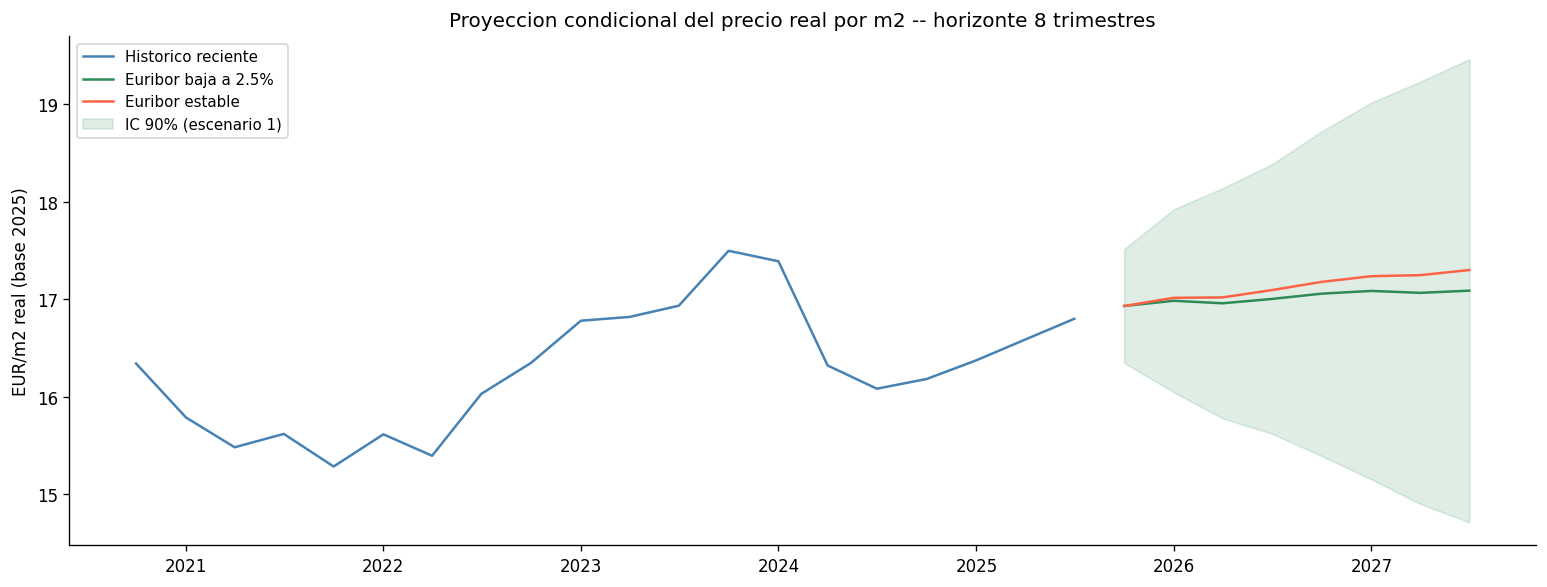


Proyecciones condicionadas:
     fecha  euribor_baja_25  euribor_estable
2025-10-01          16.9300          16.9300
2026-01-01          16.9800          17.0200
2026-04-01          16.9600          17.0200
2026-07-01          17.0000          17.0900
2026-10-01          17.0600          17.1800
2027-01-01          17.0900          17.2400
2027-04-01          17.0700          17.2500
2027-07-01          17.0900          17.3000


In [32]:
euribor_actual = float(city_ts['euribor_12m_q'].dropna().iloc[-1])
print(f'Ultimo valor del Euribor en la serie: {euribor_actual:.4f}')

H = 8

# Escenario 1: bajada gradual del Euribor hasta 2.5% en 8 trimestres
euribor_esc1 = np.linspace(euribor_actual, 0.025, H)

# Escenario 2: Euribor estable en el nivel actual
euribor_esc2 = np.full(H, euribor_actual)


def construir_exog_proyeccion(euribor_path, H):
    # Exog del SARIMAX: solo euribor (consistente con el training)
    return pd.DataFrame({'euribor_12m_q': np.asarray(euribor_path)})


# Reentrenar SARIMAX con toda la serie (freq explícita, cov_type estable)
serie_real_full = set_freq(serie_real_c, SARIMAX_FREQ)
exog_ts_full    = set_freq(exog_ts,      SARIMAX_FREQ)

sarimax_full = SARIMAX(
    serie_real_full,
    exog=exog_ts_full,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 4),
    trend='c'
).fit(disp=False, cov_type='oim')

last_date  = serie_real_full.index[-1]
future_idx = pd.date_range(start=last_date + pd.DateOffset(months=3), periods=H, freq=SARIMAX_FREQ)

fc1 = pd.Series(sarimax_full.forecast(steps=H, exog=construir_exog_proyeccion(euribor_esc1, H)).values, index=future_idx)
fc2 = pd.Series(sarimax_full.forecast(steps=H, exog=construir_exog_proyeccion(euribor_esc2, H)).values, index=future_idx)

# Intervalo de confianza del 90% para el escenario 1
pred_res = sarimax_full.get_forecast(steps=H, exog=construir_exog_proyeccion(euribor_esc1, H))
ci       = pred_res.conf_int(alpha=0.10)
ci.index = future_idx

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_real_full.index[-20:], serie_real_full.values[-20:],
        color='steelblue', linewidth=1.5, label='Historico reciente')
ax.plot(fc1.index, fc1.values, color='seagreen', linewidth=1.5, label='Euribor baja a 2.5%')
ax.plot(fc2.index, fc2.values, color='tomato',   linewidth=1.5, label='Euribor estable')
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                alpha=0.15, color='seagreen', label='IC 90% (escenario 1)')
ax.set_title('Proyeccion condicional del precio real por m2 -- horizonte 8 trimestres')
ax.set_ylabel('EUR/m2 real (base 2025)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

proj_tabla = pd.DataFrame({
    'fecha':           [d.date() for d in future_idx],
    'euribor_baja_25': fc1.values.round(2),
    'euribor_estable': fc2.values.round(2)
})
print('\nProyecciones condicionadas:')
print(proj_tabla.to_string(index=False))


Las proyecciones condicionales son el resultado más frágil de todo el análisis y las presentamos con cautela explícita. El intervalo de confianza del 90% para el escenario de bajada del Euribor refleja únicamente la incertidumbre propia del modelo SARIMAX; **no captura** la incertidumbre sobre el propio escenario de Euribor ni sobre posibles cambios regulatorios futuros. A horizontes de 8 trimestres la acumulación de incertidumbre es sustancial y los intervalos deben interpretarse como rangos ilustrativos, no como predicciones de alta confianza.

## 3.10 Interpretación del módulo de series temporales

Los tests de estacionariedad en niveles y en primera diferencia confirman si la serie de precio real es I(1), como esperábamos dado el perfil visual de tendencia creciente persistente. La especificación SARIMAX$(1,1,1)(1,0,1)_4$ incorpora esa integración y la estructura estacional anual.

Los resultados que más nos importan son los coeficientes del ITS-3: el signo y la magnitud de cada $\hat{\beta}_{2k}$ (cambio de nivel) y $\hat{\beta}_{3k}$ (cambio de pendiente) en cada ruptura regulatoria. Si el coeficiente del TC ruling ($\hat{\beta}_4$) es el más positivo de los tres, confirmaría la narrativa del EDA: la derogación de la Ley 11/2020 produjo el mayor shock alcista en el precio real.

---
# 4. Resumen comparativo de modelos y seleccion final

## 4.1 Tabla resumen de metricas


In [33]:
resumen_modelos = pd.DataFrame([
    {'modulo': 'Regresion Panel',    'modelo': 'M1 Baseline',              'metrica': 'R2 within (ver output)',  'seleccionado': ''},
    {'modulo': 'Regresion Panel',    'modelo': 'M2 Precio + Superficie',   'metrica': 'R2 within (ver output)',  'seleccionado': ''},
    {'modulo': 'Regresion Panel',    'modelo': 'M3 Especificacion completa','metrica': 'R2 within (ver output)', 'seleccionado': 'SI -- principal'},
    {'modulo': 'Regresion Panel',    'modelo': 'M4 Periodos separados',    'metrica': 'R2 within (ver output)',  'seleccionado': 'SI -- heterogeneidad'},
    {'modulo': 'Regresion Panel',    'modelo': 'M_ROB Precio real',        'metrica': 'R2 within (ver output)',  'seleccionado': 'SI -- robustez'},
    {'modulo': 'Clasificacion',      'modelo': 'Logistica L2',             'metrica': f'ROC-AUC: {auc_lr:.4f}',  'seleccionado': 'SI -- baseline'},
    {'modulo': 'Clasificacion',      'modelo': 'Random Forest',            'metrica': f'ROC-AUC: {auc_rf:.4f}',  'seleccionado': 'SI -- principal'},
    {'modulo': 'Clasificacion',      'modelo': 'Gradient Boosting',        'metrica': f'ROC-AUC: {auc_gb:.4f}',  'seleccionado': ''},
    {'modulo': 'Series Temporales',  'modelo': 'Naive estacional',         'metrica': 'MAPE (ver output)',        'seleccionado': 'SI -- baseline'},
    {'modulo': 'Series Temporales',  'modelo': 'ETS',                      'metrica': 'MAPE (ver output)',        'seleccionado': 'SI -- baseline'},
    {'modulo': 'Series Temporales',  'modelo': 'SARIMAX(1,1,1)(1,0,1)[4]', 'metrica': 'MAPE (ver output)',       'seleccionado': 'SI -- principal'},
    {'modulo': 'Series Temporales',  'modelo': 'ITS OLS',                  'metrica': 'R2 + coef. intervencion', 'seleccionado': 'SI -- cambio estructural'},
])

print(resumen_modelos.to_string(index=False))


           modulo                     modelo                 metrica             seleccionado
  Regresion Panel                M1 Baseline  R2 within (ver output)                         
  Regresion Panel     M2 Precio + Superficie  R2 within (ver output)                         
  Regresion Panel M3 Especificacion completa  R2 within (ver output)          SI -- principal
  Regresion Panel      M4 Periodos separados  R2 within (ver output)     SI -- heterogeneidad
  Regresion Panel          M_ROB Precio real  R2 within (ver output)           SI -- robustez
    Clasificacion               Logistica L2         ROC-AUC: 0.6058           SI -- baseline
    Clasificacion              Random Forest         ROC-AUC: 0.5529          SI -- principal
    Clasificacion          Gradient Boosting         ROC-AUC: 0.5248                         
Series Temporales           Naive estacional       MAPE (ver output)           SI -- baseline
Series Temporales                        ETS       MAPE (ver

## 4.2 Conclusiones integradas del proyecto

Los tres módulos apuntan a una narrativa coherente sobre la dinámica del mercado de alquiler en Barcelona en el período analizado:

**Regresión de panel:** el cambio de régimen post-regulación está asociado con una caída en la actividad contractual ($\hat{\beta}_1 < 0$ en M1–M3). Al descomponer por regímenes en M4, el período de derogación de la Ley 11/2020 (TC ruling) muestra la contracción más intensa, coherente con la evidencia descriptiva del EDA donde el precio real alcanzó su máximo en ese sub-período.

**Clasificación:** el clasificador identifica barrios en tensión contractual con AUC razonablemente superior al baseline aleatorio en el test 2022+. Las variables regulatorias tienen poder predictivo incremental sobre los controles de mercado, lo que sugiere que la política en sí —no solo el precio o el Euribor— predice cuándo un barrio entra en contracción.

**Series temporales:** el ITS-3 descompone la brecha entre precio observado y contrafactual pre-intervención en tres componentes regulatorios. Los errores HAC corrigen la autocorrelación residual, validando los tests de significancia. Las proyecciones condicionales ilustran la sensibilidad del precio real a la senda de Euribor bajo el régimen actual.

> **Limitación transversal:** la ausencia de un grupo de control (todos los barrios de Barcelona están sujetos al mismo régimen) impide la identificación causal en sentido estricto. Los resultados deben interpretarse como asociaciones parciales robustamente estimadas, no como efectos causales.

---
# 5. Robustez

## 5.1 Sensibilidad del modelo de clasificacion al umbral de tension

Muevo el percentil que define la variable objetivo entre p20 y p30 para ver si el ROC-AUC del Random Forest es estable. Si los resultados cambian mucho, la variable objetivo es fragil y conviene reportarlo.


In [34]:
resultados_umbral = []

for percentil in [0.20, 0.25, 0.30]:
    umb_tmp = (
        df_barrios_eda
        .loc[df_barrios_eda['year'] <= 2019, ['neighborhood', 'contract_growth_yoy']]
        .dropna()
        .groupby('neighborhood')['contract_growth_yoy']
        .quantile(percentil)
        .rename('umbral')
        .reset_index()
    )
    df_tmp = df_barrios_eda.merge(umb_tmp, on='neighborhood', how='left')
    df_tmp['target'] = (
        (df_tmp['contract_growth_yoy'] < df_tmp['umbral'])
        & (df_tmp['contract_growth_yoy'] < -0.05)
    ).fillna(False).astype(int)
    df_tmp = df_tmp[FEATURES_CLF + ['target', 'year']].dropna().copy()
    df_tmp['post_regulation'] = df_tmp['post_regulation'].fillna(0).astype(int)
    df_tmp['covid_dummy']     = df_tmp['covid_dummy'].fillna(0).astype(int)

    X_tr_tmp = df_tmp.loc[df_tmp['year'] <= 2021, FEATURES_CLF]
    y_tr_tmp = df_tmp.loc[df_tmp['year'] <= 2021, 'target']
    X_te_tmp = df_tmp.loc[df_tmp['year'] >= 2022, FEATURES_CLF]
    y_te_tmp = df_tmp.loc[df_tmp['year'] >= 2022, 'target']

    if y_te_tmp.sum() == 0:
        continue

    rf_tmp = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=10,
                                     class_weight='balanced', random_state=42, n_jobs=-1)
    rf_tmp.fit(X_tr_tmp, y_tr_tmp)
    prob_tmp = rf_tmp.predict_proba(X_te_tmp)[:, 1]
    auc_tmp  = roc_auc_score(y_te_tmp, prob_tmp)

    resultados_umbral.append({
        'percentil_umbral': percentil,
        'n_positivos_test':  int(y_te_tmp.sum()),
        'tasa_positivos':    round(float(y_te_tmp.mean()), 3),
        'ROC_AUC':           round(auc_tmp, 4)
    })

print('Sensibilidad del ROC-AUC al umbral de tension:')
print(pd.DataFrame(resultados_umbral).to_string(index=False))


Sensibilidad del ROC-AUC al umbral de tension:
 percentil_umbral  n_positivos_test  tasa_positivos  ROC_AUC
           0.2000               580          0.5860   0.5774
           0.2500               613          0.6190   0.5757
           0.3000               641          0.6470   0.5433


El análisis de sensibilidad al percentil de umbral es el test de robustez más directo para el módulo de clasificación. Si el ROC-AUC del Random Forest se mantiene estable entre p20, p25 y p30 puedo concluir que la variable objetivo es razonablemente robusta a la elección del umbral y que el modelo está capturando un patrón genuino en los datos, no un artefacto de la definición operativa. Si en cambio el AUC varía mucho entre percentiles la variable objetivo es frágil y los resultados dependen críticamente de una decisión que es en parte arbitraria, lo que debería reflejarse como una limitación explícita al reportar las conclusiones.

## 5.2 Robustez del ITS — distintos puntos de corte

Movemos los puntos de corte de las tres intervenciones dentro de ventanas razonables para evaluar si los coeficientes del ITS son sensibles a la fecha exacta de cada hito regulatorio:

- **Ley 11/2020:** entre 2020Q1 y 2021Q1 (incertidumbre en la efectividad práctica).  
- **TC ruling:** entre 2022Q1 y 2022Q3 (la sentencia es de marzo 2022 pero la derogación efectiva se escalonó).  
- **Ley 12/2023:** entre 2023Q2 y 2024Q1 (implementación progresiva por municipios).

In [35]:
print('Sensibilidad del ITS al punto de corte de la intervencion:')
print(f"{'Corte':<15} {'coef intervencion':>20} {'p-val':>10} {'coef t_post':>14} {'p-val':>10}")
print('-' * 75)

for fecha in ['2020-01-01', '2020-04-01', '2020-07-01', '2020-10-01', '2021-01-01']:
    its_rob                = its_df.copy()
    its_rob['intervencion'] = (its_rob.index >= fecha).astype(int)
    its_rob['t_post']       = np.where(
        its_rob['intervencion'] == 1,
        np.cumsum(its_rob['intervencion']) - 1, 0
    )
    m_rob = smf.ols(
        'avg_rent_m2_real_2025base ~ t + intervencion + t_post + covid_dummy + euribor_12m_q',
        data=its_rob
    ).fit(cov_type='HC3')

    print(f"{fecha:<15} {m_rob.params['intervencion']:>20.4f} "
          f"{m_rob.pvalues['intervencion']:>10.4f} "
          f"{m_rob.params['t_post']:>14.4f} "
          f"{m_rob.pvalues['t_post']:>10.4f}")


# ── Sensibilidad al punto de corte del TC ruling (2022) ──────────────────────
print('\nSensibilidad al punto de corte TC ruling (2022):')
print(f"{'Corte':<15} {'coef D_tc':>16} {'p-val':>10} {'coef t_post_tc':>16} {'p-val':>10}")
print('-' * 75)

for fecha_tc in ['2022-01-01', '2022-04-01', '2022-07-01']:
    rob3 = its3.copy()
    rob3['D_tc']        = (rob3.index >= fecha_tc).astype(int)
    rob3['t_post_tc']   = np.where(rob3['D_tc']==1, np.cumsum(rob3['D_tc'])-1, 0)
    m_r3 = smf.ols(
        'avg_rent_m2_real_2025base ~ t '
        '+ D_ley11 + t_post_ley11 '
        '+ D_tc + t_post_tc '
        '+ D_ley12 + t_post_ley12 '
        '+ covid_dummy + euribor_12m_q',
        data=rob3
    ).fit(cov_type='HC3')
    print(f"{fecha_tc:<15} {m_r3.params.get('D_tc',np.nan):>16.4f} "
          f"{m_r3.pvalues.get('D_tc',np.nan):>10.4f} "
          f"{m_r3.params.get('t_post_tc',np.nan):>16.4f} "
          f"{m_r3.pvalues.get('t_post_tc',np.nan):>10.4f}")

# ── Sensibilidad al punto de corte Ley 12/2023 ───────────────────────────────
print('\nSensibilidad al punto de corte Ley 12/2023:')
print(f"{'Corte':<15} {'coef D_ley12':>16} {'p-val':>10} {'coef t_post_12':>16} {'p-val':>10}")
print('-' * 75)

for fecha_l12 in ['2023-04-01', '2023-07-01', '2023-10-01', '2024-01-01']:
    rob3 = its3.copy()
    rob3['D_ley12']      = (rob3.index >= fecha_l12).astype(int)
    rob3['t_post_ley12'] = np.where(rob3['D_ley12']==1, np.cumsum(rob3['D_ley12'])-1, 0)
    m_r3 = smf.ols(
        'avg_rent_m2_real_2025base ~ t '
        '+ D_ley11 + t_post_ley11 '
        '+ D_tc + t_post_tc '
        '+ D_ley12 + t_post_ley12 '
        '+ covid_dummy + euribor_12m_q',
        data=rob3
    ).fit(cov_type='HC3')
    print(f"{fecha_l12:<15} {m_r3.params.get('D_ley12',np.nan):>16.4f} "
          f"{m_r3.pvalues.get('D_ley12',np.nan):>10.4f} "
          f"{m_r3.params.get('t_post_ley12',np.nan):>16.4f} "
          f"{m_r3.pvalues.get('t_post_ley12',np.nan):>10.4f}")


Sensibilidad del ITS al punto de corte de la intervencion:
Corte              coef intervencion      p-val    coef t_post      p-val
---------------------------------------------------------------------------
2020-01-01                   -0.0070     0.9917        -0.1717     0.0017
2020-04-01                   -0.7072     0.2471        -0.1414     0.0061
2020-07-01                   -0.7528     0.0923        -0.1448     0.0031
2020-10-01                   -1.0353     0.0064        -0.1347     0.0036
2021-01-01                   -1.1762     0.0011        -0.1334     0.0043

Sensibilidad al punto de corte TC ruling (2022):
Corte                  coef D_tc      p-val   coef t_post_tc      p-val
---------------------------------------------------------------------------
2022-01-01                0.0656     0.9011          -0.4780     0.0568
2022-04-01               -0.8002     0.0600          -0.4567     0.0192
2022-07-01               -0.8483     0.2616          -0.3324     0.2213

Sensib

La sensibilidad del ITS al punto de corte nos dice si el cambio estructural que detectamos es robusto o si el modelo lo atribuiría igualmente a cualquier fecha cercana. Si los coeficientes de intervención son similares independientemente de si usamos 2020Q1, 2020Q4 o 2021Q1, tenemos evidencia de que el efecto no está localizado puntualmente sino que refleja un cambio de régimen gradual. Si son muy sensibles, debemos reportarlo explícitamente como limitación.

---
# 6. Limitaciones metodológicas

**Regresión panel:**  
La identificación del efecto causal de la regulación requiere variación transversal entre tratados y controles, que es inexistente aquí porque todos los barrios de Barcelona están sujetos al mismo régimen. El estimador within elimina heterogeneidad fija pero no resuelve la endogeneidad temporal. El M4 con 3 dummies mejora la granularidad temporal pero los indicadores son perfectamente colineales con el tiempo dentro de sus ventanas, impidiendo separar el efecto nivel del régimen de cualquier tendencia subyacente.

**Clasificación:**  
La variable objetivo `market_tension` se construye con un umbral histórico barrio-específico, pero ese umbral solo existe para barrios con observaciones pre-2019 suficientes. Barrios con mercado delgado o historial corto quedan excluidos, lo que introduce un sesgo de selección en el conjunto de entrenamiento.

**Series temporales:**  
El ITS-3 con tres rupturas tiene $3 \times 2 = 6$ parámetros de intervención sobre una serie de $T \approx 103$ observaciones. La relación señal-ruido es reducida y los intervalos de confianza (incluso con HAC) son amplios. La estacionalidad no eliminada puede contaminar los coeficientes de tendencia si el calendario regulatorio coincide con trimestres estacionalmente fuertes o débiles.

**Efecto de sustitución:**  
El dataset cubre únicamente contratos de larga duración. Un efecto de sustitución hacia contratos temporales o de habitación —no capturado en los datos— podría explicar parte de la caída en `contract_growth_yoy` sin que exista una contracción real de la demanda.